In [1]:
pathout = ".."

import sys
sys.path.append(pathout)
from TheModel import *
import os

In [2]:
########### Params for entire Notebook ############
epsi=.005
C=15
s=0.25
###################################################

alpha=[.08,.08]
tmax=5*360
mmax=0


p = {
        'y0':[1-epsi,0,0,epsi,0,0,0,0,0,0,0],
        'beta': [C*alpha[0],C*alpha[1]],
        'alpha': alpha,
        'gamma': [.1,.1],
        'nu': [.01,.01],
        'tmin': 0,
        'tmax': tmax,
        'stepsize': 0.1,      
        'maxstep': 10,
        'direction': True,
        's': s,              # seasonality amplitude
        'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
        'seasonalshift': 0,
        'mmax': mmax, #0.845,
        'hthres': 2*1/1000,
        'epsilon_m': 2*0.00025, # =0.0005
        'tau': 36,
        'distinguishable': False,
    }

###############################
InInfComp = 'A and B' ######### 'A and B' or 'AB' Doesnt change much because we start at alpha=0.12 away from the basin boarder. Need lower tolerances though
###############################

## ANALYSIS: Symmetric Model with Seas. & Beh Feedback

### Case: C = 15, $\epsilon$ = .005, SS = 0, $\alpha=0.12$, for different $m_{\rm max}$ and RateFractions

In [ ]:
C = 15
epsi = .005

################################# Endemic and Unstable Equilibrium for different C=15 ################################
#Analytical
alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
TheMask = R0_EE <= 1
######################################################################################################################

In [4]:
p['seasonalshift'] = 0
p['w'] = 2*np.pi/360
epsi = 0.005
SetInCondfullSIRS(epsi, p, InInfComp)

1

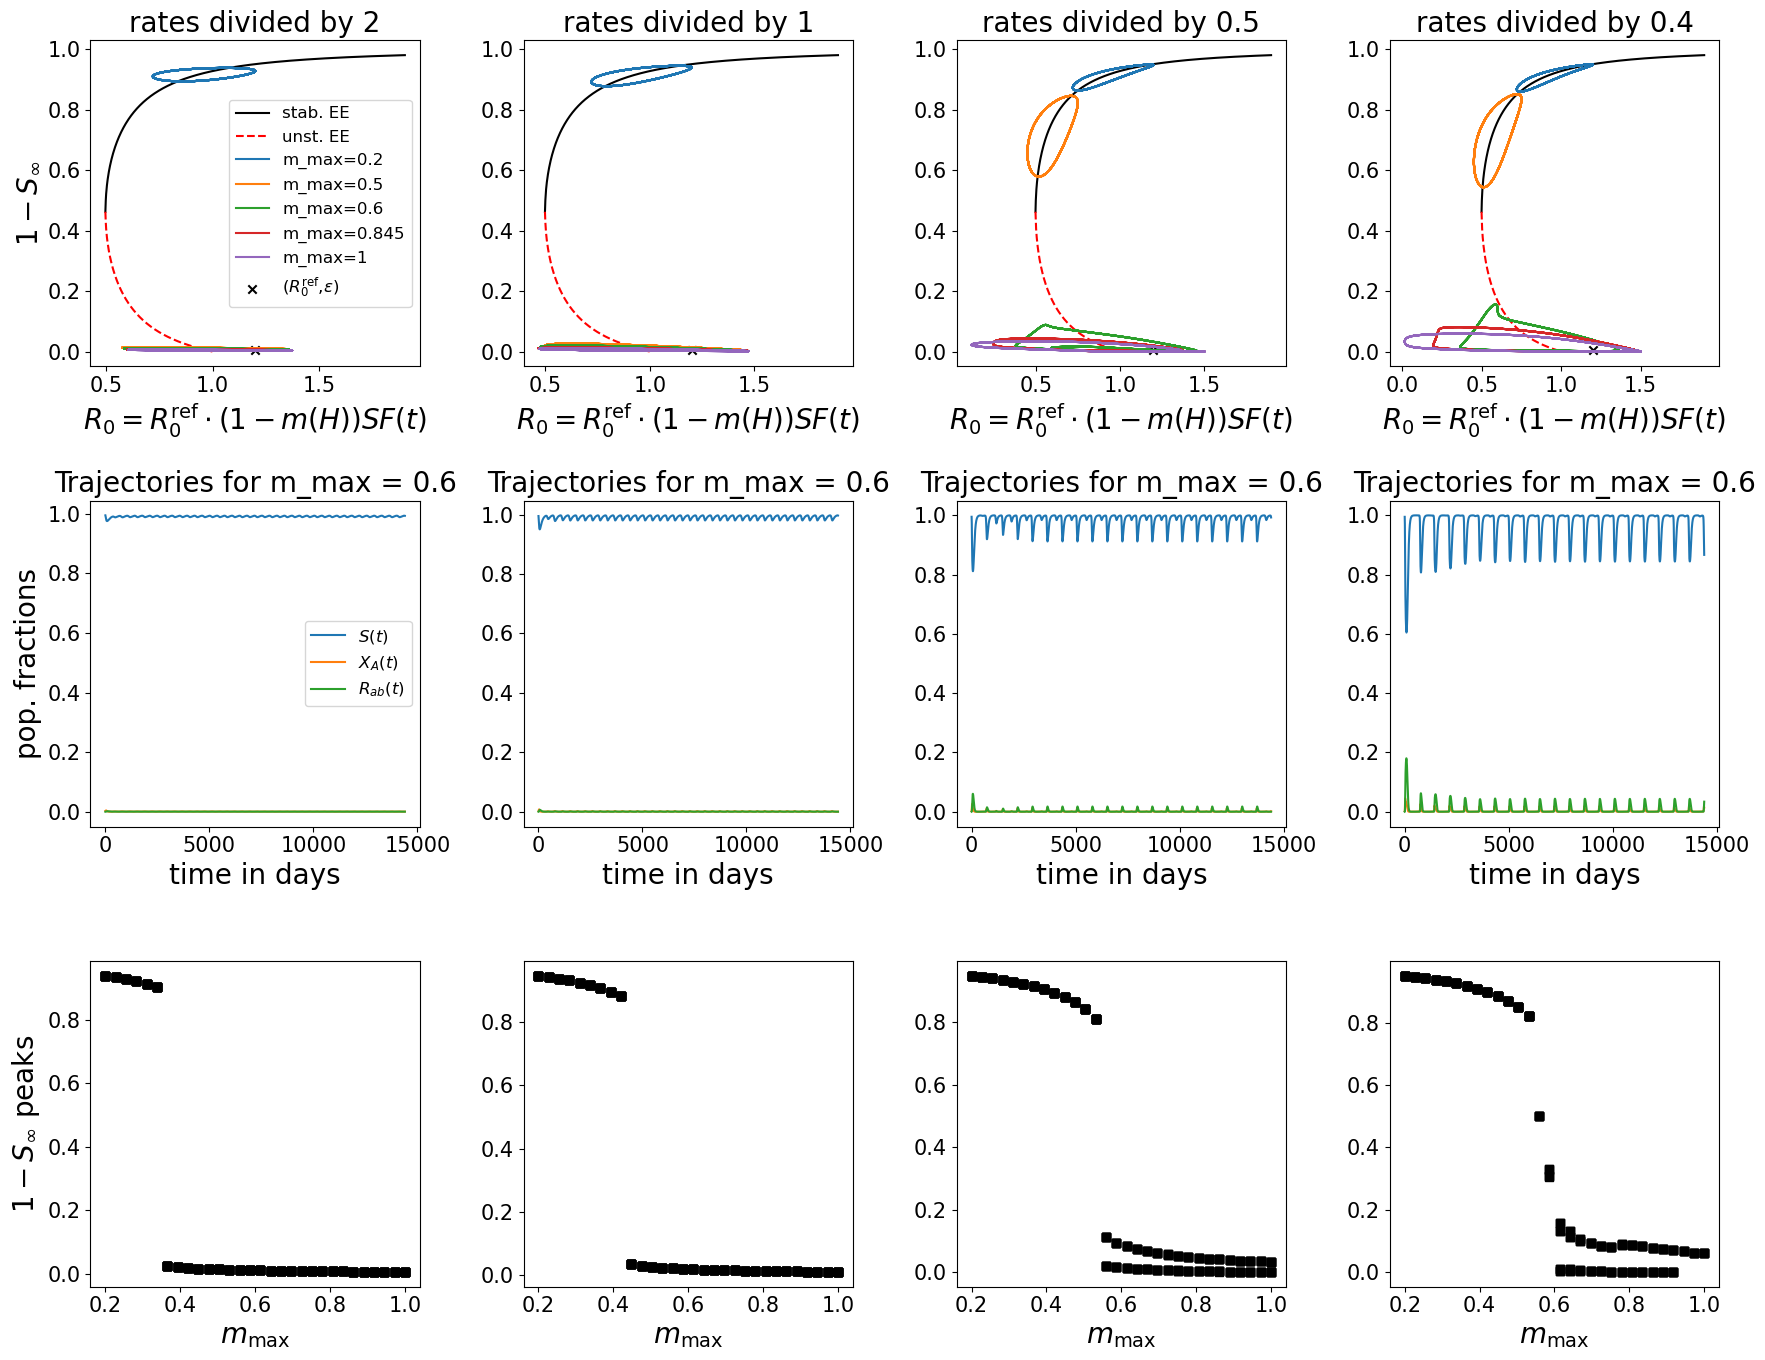

In [5]:
fraction = [2,1,.5,.4]
mmax_values = [.2,.5,.6,.845,1]
p['s'] = 0.25

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k]
    mmax = .6
    p['mmax'] = mmax
    p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles
    
    try:
        m = model(**p)
        times, Data = m.run()
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        
        ax1 = axes[1, k] 
        ax1.plot(times, S, label=r'$S(t)$')
        ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
        ax1.plot(times, ab, label=r'$R_{ab}(t)$')
        #plt.plot(times,Q, label=rf'Q')
        #plt.plot(times,A, label=rf'A')
        #plt.plot(times,AB, label=rf'AB')
        #plt.plot(times,X,label='X')
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

    ax1.set_xlabel(r'time in days')
    ax1.set_title(rf'Trajectories for m_max = {mmax}')
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')

    for mmax in mmax_values:
        p['mmax'] = mmax

        try:
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
            
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        
        ax2.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}')
    
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
    if(k==0): ax2.legend()
    ax2.set_title(rf'rates divided by {fraction[k]}')

    ###########################################################

    ax3 = axes[2, k]

    for mmax in np.linspace(min(mmax_values),max(mmax_values),30):
        p['mmax'] = mmax
        try:
            m = model(**p)
            times, Data = m.run()
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            peak_idces, _ = scp.signal.find_peaks(1-S)
            for idx in peak_idces: ax3.scatter(mmax, 1-S[idx], marker=',', c='k') 
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass

        ax3.set_xlabel(r'$m_{\rm max}$')
    
    if(k==0): 
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(r'pop. fractions')
        ax3.set_ylabel(r'$1-S_\infty$ peaks')
        
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

# p['gamma'] = np.full(2,.1)
# p['alpha'] = alpha_crit
# p['beta'] = np.full(2,C*alpha_crit)
# p['nu'] = np.full(2,.01)

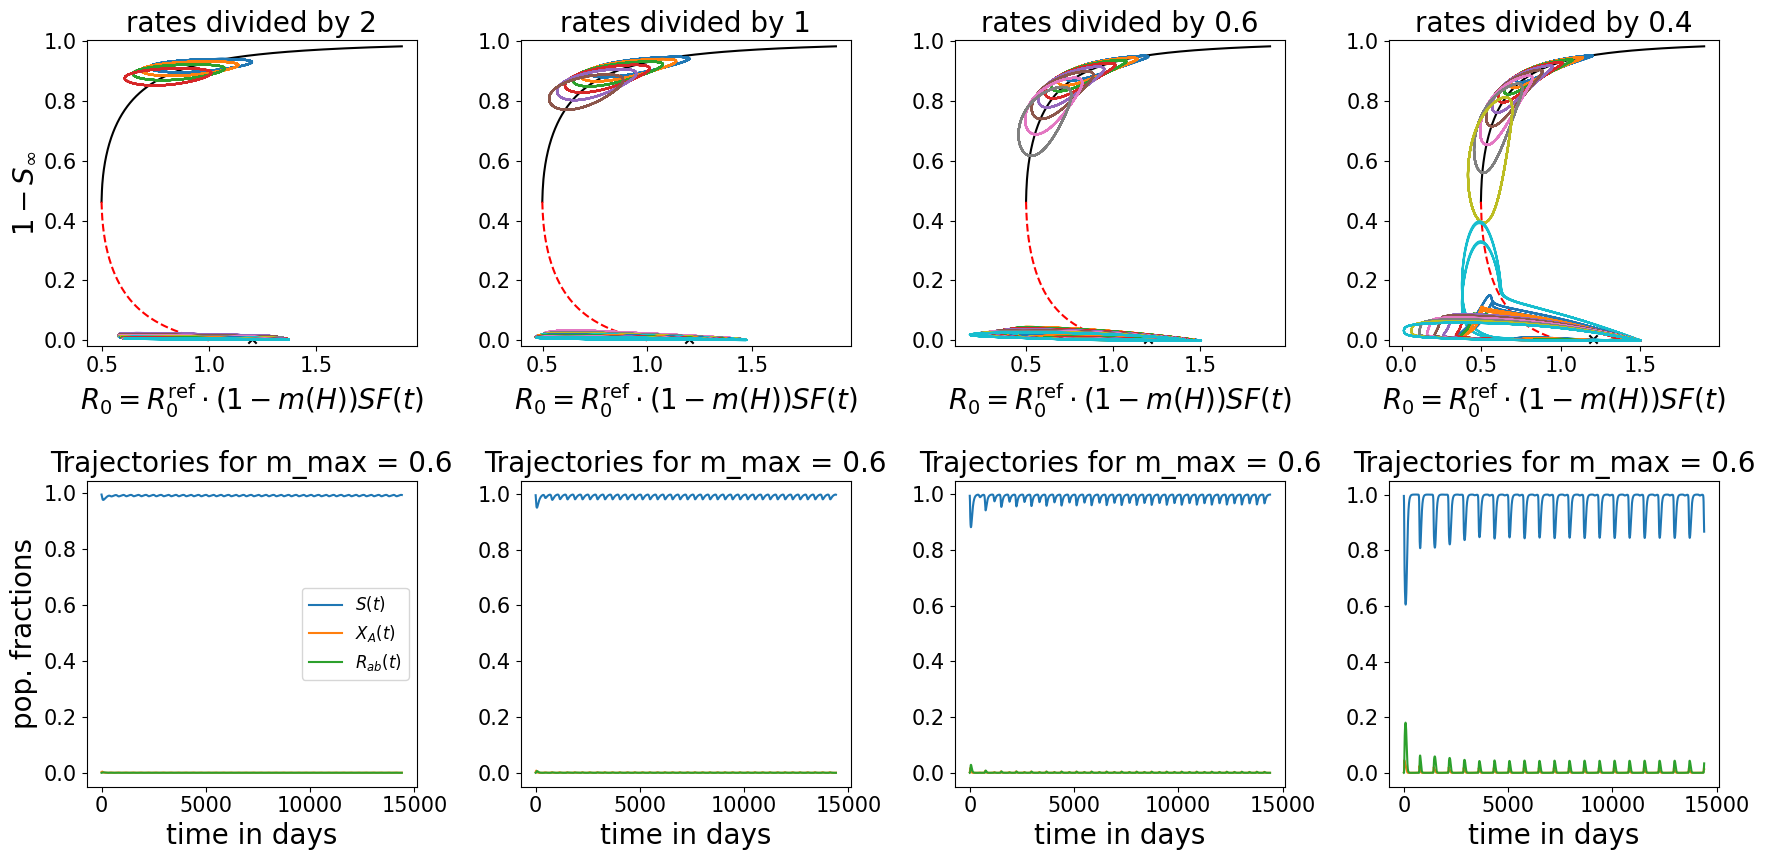

In [ ]:
fraction = [2,1,.6,.4]
mmax_values = np.linspace(.2,1,20)
p['s'] = 0.25

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k]
    mmax = .6
    p['mmax'] = mmax
    p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles
    
    try: 
        m = model(**p)
        times, Data = m.run()
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        
        ax1 = axes[1, k] 
        ax1.plot(times, S, label=r'$S(t)$')
        ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
        ax1.plot(times, ab, label=r'$R_{ab}(t)$')
        #plt.plot(times,Q, label=rf'Q')
        #plt.plot(times,A, label=rf'A')
        #plt.plot(times,AB, label=rf'AB')
        #plt.plot(times,X,label='X')
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

    ax1.set_xlabel(r'time in days')
    ax1.set_title(rf'Trajectories for m_max = {mmax}')
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
    
    for mmax in mmax_values:
        p['mmax'] = mmax
        try:
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        
        ax2.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}')
    
    #ax2.set_xlim(-.1,1.6)
    ax2.set_ylim(-.02,max(R_inf_endEq)+.02)
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
    if(k==0): 
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(r'pop. fractions')
    #if(k==0): ax2.legend()
    ax2.set_title(rf'rates divided by {fraction[k]}')

plt.tight_layout()
plt.show()

# p['gamma'] = np.full(2,.1)
# p['alpha'] = alpha_crit
# p['beta'] = np.full(2,C*alpha_crit)
# p['nu'] = np.full(2,.01)

at mmax= 0.7473684210526317 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.7894736842105263 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.831578947368421 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.8736842105263158 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.9157894736842105 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 0.9578947368421054 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 1.0 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.


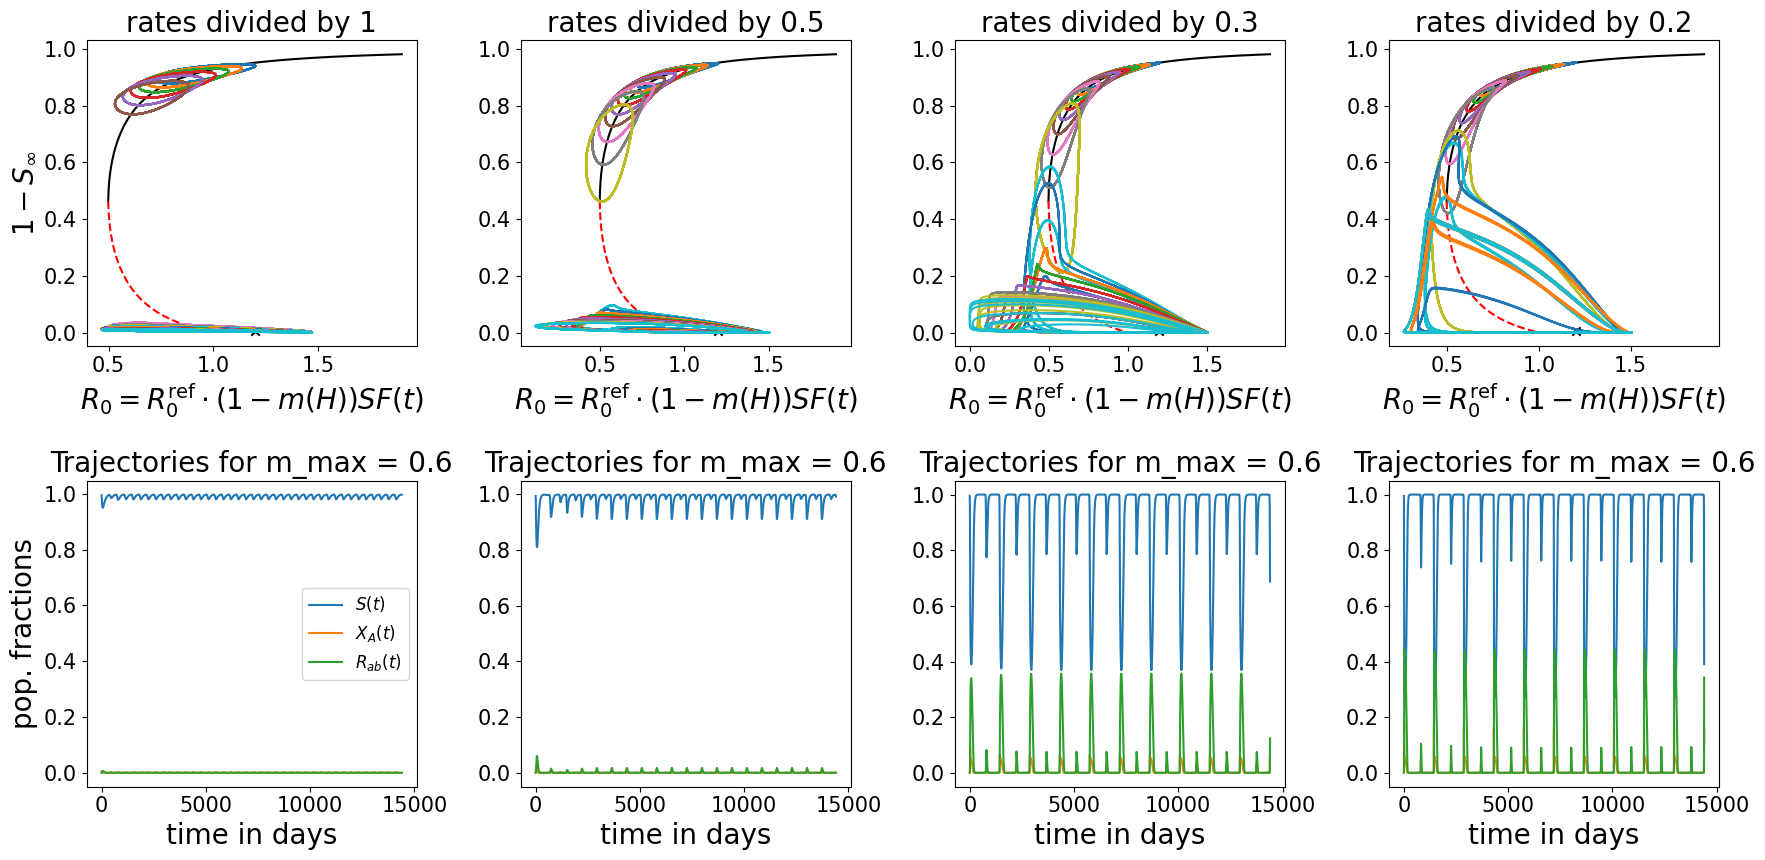

In [ ]:
C = 15

fraction = [1,.5,.3,.2]
mmax_values = np.linspace(.2,1,20)
p['s'] = 0.25

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k]
    mmax = .6
    p['mmax'] = mmax
    p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles
    
    try: 
        m = model(**p)
        times, Data = m.run()
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        
        ax1 = axes[1, k] 
        ax1.plot(times, S, label=r'$S(t)$')
        ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
        ax1.plot(times, ab, label=r'$R_{ab}(t)$')
        #plt.plot(times,Q, label=rf'Q')
        #plt.plot(times,A, label=rf'A')
        #plt.plot(times,AB, label=rf'AB')
        #plt.plot(times,X,label='X')
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

    ax1.set_xlabel(r'time in days')
    ax1.set_title(rf'Trajectories for m_max = {mmax}')
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
    
    for mmax in mmax_values:
        p['mmax'] = mmax
        try:
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        
        ax2.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}')
    
    # ax2.set_ylim(-.02,max(R_inf_endEq)+.02)
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
    if(k==0): 
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(r'pop. fractions')
    #if(k==0): ax2.legend()
    ax2.set_title(rf'rates divided by {fraction[k]}')

plt.tight_layout()
plt.show()

# p['gamma'] = np.full(2,.1)
# p['alpha'] = alpha_crit
# p['beta'] = np.full(2,C*alpha_crit)
# p['nu'] = np.full(2,.01)

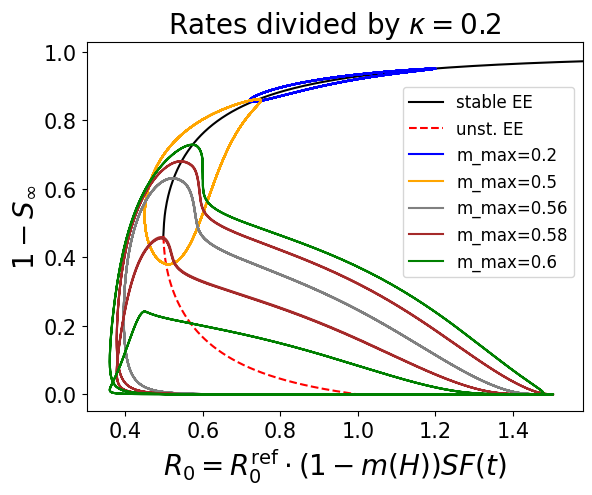

In [ ]:
fraction = .2
mmax_values = [.2,.5,.56,.58,.6]
p['s'] = 0.25

COL = ['b','orange','gray','brown','g']

p['gamma'] = .1/fraction
p['alpha'] = .12/fraction
p['nu'] = .01/fraction
p['beta'] = C*.12/fraction
p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
cut = int(p['tmax']/p['stepsize']*7/10)  # cut out relaxation into limit cycles

plt.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stable EE')
plt.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')

for mmax in mmax_values:
    p['mmax'] = mmax
    try:
        m = model(**p)
        times, Data = m.run()
        times = times[cut:]
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
        SF = m.seasonalforcing(times)
        SoftPlus = 1 - mmax * m.m_normalized(H)
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction,"ERROR:", errormessage)
        pass
    
    plt.plot(p['alpha'] * SoftPlus*SF/p['gamma'], 1 - S, label=rf'm_max={mmax}', c=COL[mmax_values.index(mmax)])

plt.xlim(0.3,1.58)
#plt.ylim(-.02,max(R_inf_endEq)+.02)
#plt.scatter(p['alpha'], epsi, marker='x', c='k', label=r'($\alpha$,$\epsilon$)')
plt.xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
plt.ylabel(r'$1-S_\infty$')
plt.title(rf'Rates divided by $\kappa=${fraction}')
plt.legend(bbox_to_anchor=(0, 0, 1, .9), loc='upper right')
plt.savefig('img/SIRSsm_LimitCyclesExample_FOI_vs_1-S_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()


In [ ]:

mmax_valueList = np.array([
    [0.45 + 0.01 * i for i in range(6)],
    [0.5 + 0.01 * i for i in range(6)],
    [0.55 + 0.01 * i for i in range(6)],
    [0.6 + 0.01 * i for i in range(6)]
])

p['s'] = 0.25

p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
cut = int(p['tmax']/p['stepsize']*7/10)

fraction = [1,.75,.5,.2]

Rinf = np.zeros((len(mmax_valueList),len(fraction),len(mmax_valueList[0]),2,int(p['tmax']/p['stepsize']-cut)))

for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
    for k in range(len(fraction)):
        
        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
        
        # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
        
        for mmax_idx in range(len(mmax_values)):
            p['mmax'] = mmax_values[mmax_idx]
            try:
                m = model(**p)
                times, Data = m.run()
                times = times[cut:]
                S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
                SF = m.seasonalforcing(times)
                SoftPlus = 1 - mmax_values[mmax_idx] * m.m_normalized(H)
                FOI = p['alpha'] * SoftPlus*SF
                if(len(FOI)>0):
                    Rinf[mmax_val_idx,k,mmax_idx,0,:] = FOI
                    Rinf[mmax_val_idx,k,mmax_idx,1,:] = 1-S
            except RuntimeError as errormessage:
                print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
                pass


np.save('Data/DataSIRSsm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.npy', Rinf)

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_34480\3284254085.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


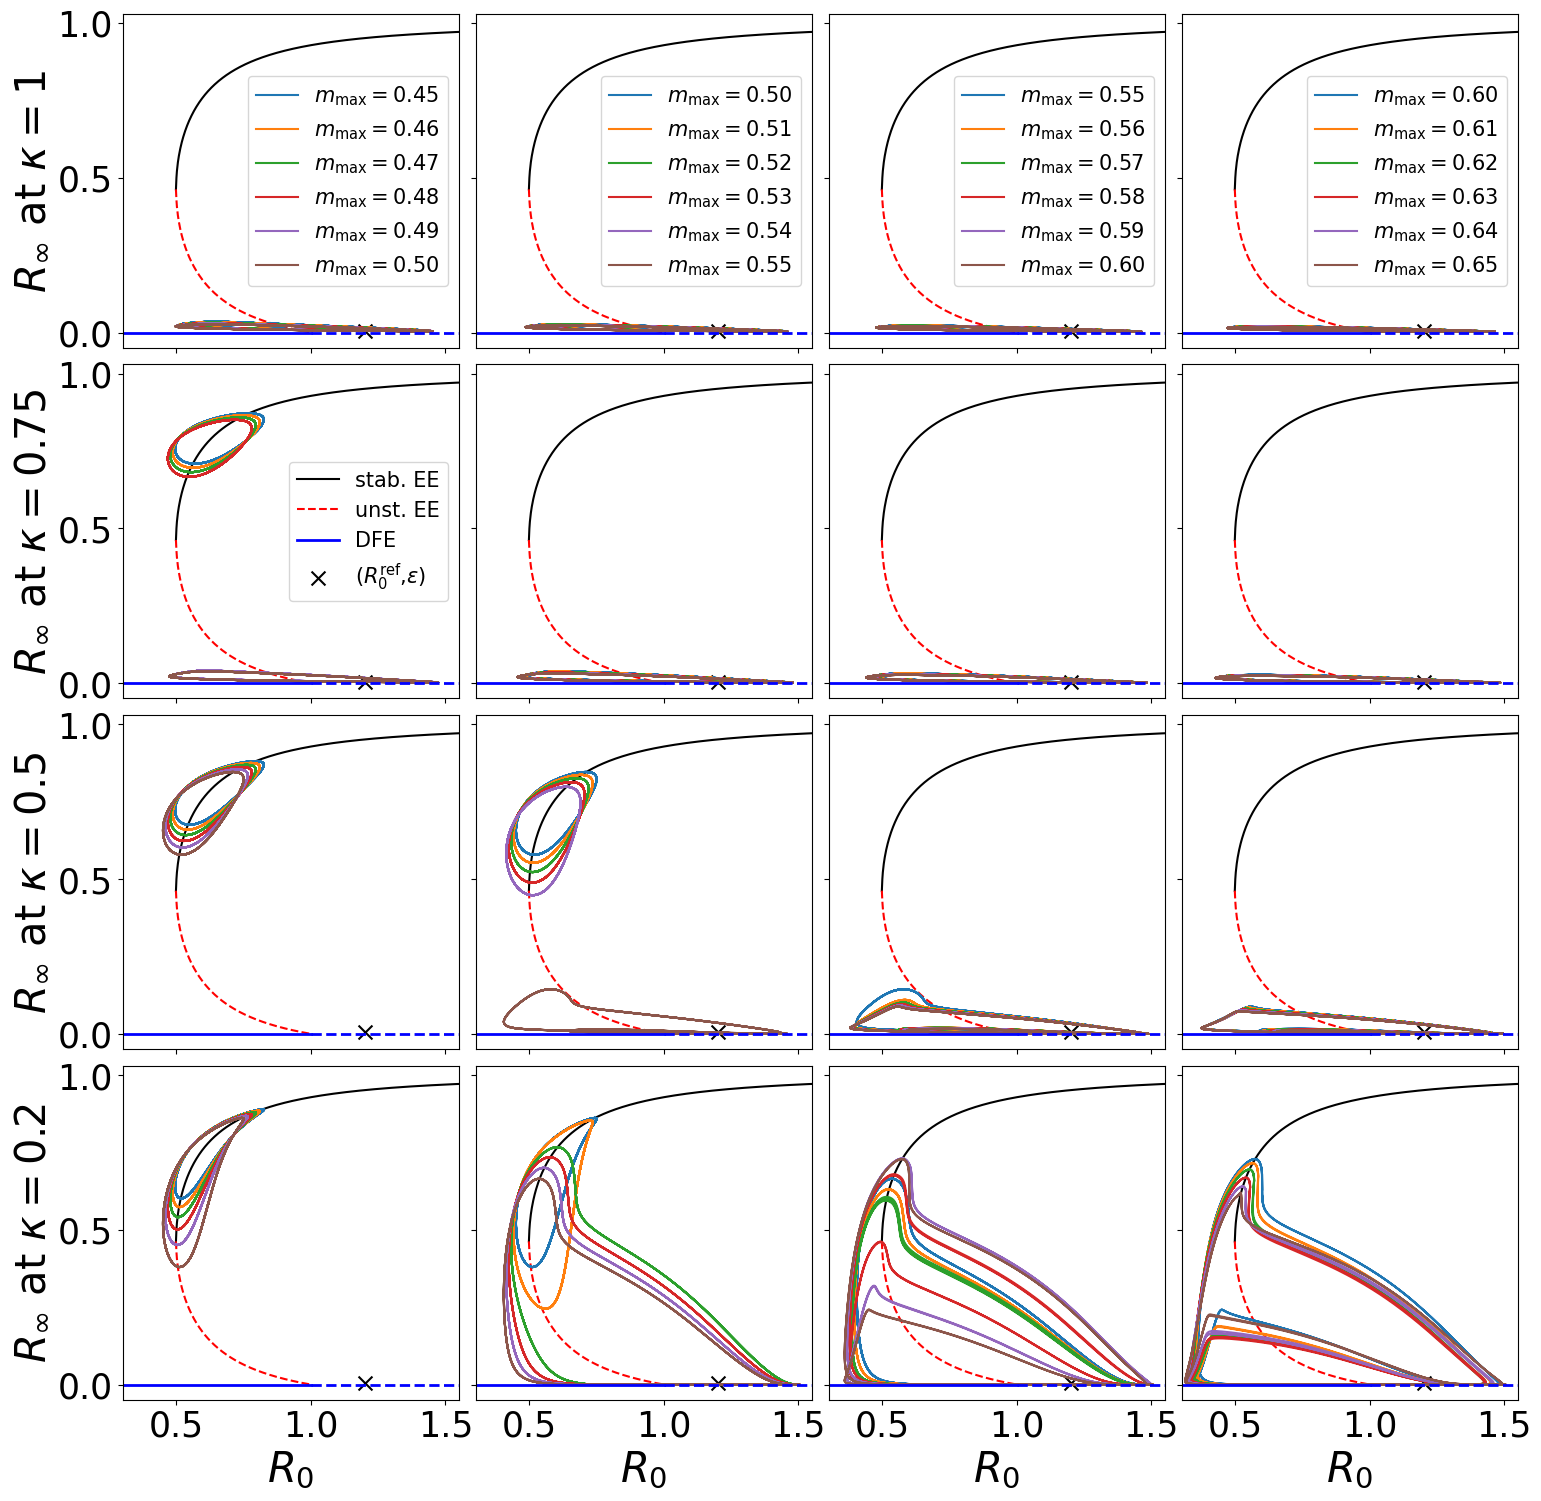

In [19]:
mmax_valueList = np.array([
    [0.45 + 0.01 * i for i in range(6)],
    [0.5 + 0.01 * i for i in range(6)],
    [0.55 + 0.01 * i for i in range(6)],
    [0.6 + 0.01 * i for i in range(6)]
])
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(mmax_valueList[0])]

fraction = [1,.75,.5,.2]

Rinf = np.load('Data/DataSIRSsm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.npy')

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 25

fig, axes = plt.subplots(4, 4, figsize=(18, 18), gridspec_kw={'wspace':0.05,'hspace':0.05})

for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
    for k in range(len(fraction)):
        p['alpha'] = 0.12/fraction[k]
        p['gamma'] = .1/fraction[k]
        R0_ref = p['alpha']/p['gamma']

        ax = axes[k, mmax_val_idx]

        ax.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE' if mmax_val_idx==0 and k==1 else None)
        ax.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE' if mmax_val_idx==0 and k==1 else None)   
        
        for mmax_idx in range(len(mmax_values)):
            FOI = Rinf[mmax_val_idx,k,mmax_idx,0,:]
            if(FOI[0] != 0): # bcs if its 0 then the solver stopped and the value of FOI and Rinf stayed as initialized at 0
                Rinf_values = Rinf[mmax_val_idx,k,mmax_idx,1,:]
                if(max(FOI)-min(FOI) < 0.01 and max(Rinf_values)-min(Rinf_values) < 0.01):
                    ax.scatter(FOI[0]/p['gamma'], Rinf_values[0], marker='x', label=r'$m_{\rm max}=$'+f'{mmax_values[mmax_idx]:.2f}' if k==0 else None, c=COL[mmax_idx])
                else: ax.plot(FOI/p['gamma'], Rinf_values, label=r'$m_{\rm max}=$'+f'{mmax_values[mmax_idx]:.2f}' if k==0 else None, c=COL[mmax_idx])

        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$ at $\kappa=${fraction[k]}')
        else: ax.tick_params(labelleft=False)
        if(k==0): ax.legend()
        
        PlotDFE(ax,x_space='R0',lw=2)
        # ax.set_ylim(-.02,max(R_inf_endEq)+.02)
        ax.scatter(R0_ref, epsi, marker='x', c='k', s=100, label=r'($R_0^{\rm ref}$,$\epsilon$)')
        if(k==3): ax.set_xlabel(r'$R_0$') # = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
        else: ax.tick_params(labelbottom=False)
        #if(mmax_val_idx==0): ax.set_title(rf'rates divided by {fraction[k]}')
        if(k==1 and mmax_val_idx==0): ax.legend()
        ax.set_xlim(0.3,1.55)

plt.tight_layout()
plt.savefig('img/SIRSsm_BLOCK_LimCycles_FOI_vs_1-S_fordiff_Ratefractions_mmax.pdf', bbox_inches='tight')
plt.show()

### Heatmap For Paper: s vs Ratefraction

In [27]:
p['mmax'] = 0.2

fraction = np.logspace(-1.5,.3,20) 
s_values = np.logspace(-0.8,0,30)

################## Colormap #######################
# SEBA SAYS THIS ONE IS NOT GOOD FOR BLIND PEOPLE 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
cm_spring = cm.get_cmap("spring")
Val1 = 0.158
Val2 = 0.908
ColStep = (Val2-Val1)/5
colors = [
    (0.0, 'k'), (0.001, 'k'), (0.001, cm_spring(0)), (Val1, cm_spring(0)),
    (Val1, 'brown'), (Val1+ColStep, 'brown'), (Val1+ColStep, 'orangered'), (Val1+ColStep*2, 'orangered'), 
    (Val1+ColStep*2, 'darkorange'), (Val1+ColStep*3, 'darkorange'), (Val1+ColStep*3, 'gold'), (Val1+ColStep*4, 'gold'), 
    (Val1+ColStep*4, 'yellow'), (Val2, 'yellow'), (Val2, 'yellow'), (1, 'yellow')
] # changed last colors from orange/gold/yellow to gold/yellow/yellow (see 'Non matching Heatmap' chapter in Symmetric Model +sm.ipynb)

cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# # COLORBLIND FRIENDLY VERSION (BUT UGLY COLORS)
# from matplotlib.colors import LinearSegmentedColormap
# Col1 = '#70362D'
# Col2 = '#8D475B'
# Col3 = 'grey'#'#916690'
# Col4 = 'grey'#'#728DBB'
# Col5 = '#2EB3CB'
# Col6 = '#15D5B8'
# Col7 = '#80EF8F'
# Col8 = '#E6FE67'
# Val1 = 0.133
# Val2 = 0.908
# ColStep = (Val2-Val1)/6
# colors = [
#     (0.0, 'k'), (0.001, 'k'), (0.001, Col1), (Val1-ColStep/8, Col1),
#     (Val1-ColStep/8, Col2), (Val1+ColStep, Col2), (Val1+ColStep, Col3), (Val1+ColStep*2, Col3), 
#     (Val1+ColStep*2, Col4), (Val1+ColStep*3, Col4), (Val1+ColStep*3, Col5), (Val1+ColStep*4, Col5), 
#     (Val1+ColStep*4, Col6), (Val2-ColStep,Col7), (Val2-ColStep, Col7), (Val2, Col8), (1, Col8)
# ]
# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

C:\Users\PCUser\AppData\Local\Temp\ipykernel_29348\809533875.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm_spring = cm.get_cmap("spring")


In [21]:
Peaks = np.empty((len(s_values),len(fraction),2)) # last "2" is [PeakValue, LimiCycleYesOrNo] to know whether its a limit cycle (1) or not (0)

SetInCondfullSIRS(epsi, p, InInfComp)

errorcounter = 0

for s_idx in range(len(s_values)):
    for k in range(len(fraction)):
        s_idx = -1-s_idx # to start with highest s

        print('computing s =',s_values[s_idx],'and fraction =',fraction[k])

        Years_evol = 100

        SetTolerances_for_kappa_s(s_values[s_idx], fraction[k], p)
        
        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] 
        
        p['tmax'] = Years_evol*360/fraction[k]
        cut = int(p['tmax']/p['stepsize']*7/10)

        
        p['s'] = s_values[s_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            Mean_R = np.mean(1-S)
            FOI = p['alpha'] * SF

            if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                Peaks[s_idx, k, 0] = np.mean(1-S)
                Peaks[s_idx, k, 1] = 0
                continue
            else: #if(max(1-S)-min(1-S)>.01):

                # # check if chaotic 1:
                # found_NotPeriodic = False
                # FOI_middlevalue = np.mean((np.max(FOI),np.min(FOI)))

                # counter = 0
                # for i in range(len(FOI)-1):
                #     if(FOI[i]<FOI_middlevalue and FOI[i+1]>=FOI_middlevalue):
                #         if(counter==0): 
                #             upper_ref = 1-S[i]
                #             counter += 1
                #         if(counter==1): 
                #             lower_ref = 1-S[i]
                #             counter += 1
                #         if(counter==2 and upper_ref-(1-S[i])>0.001 and 1-S[i]-lower_ref>0.001): # chaotic
                #             found_NotPeriodic = True
                #             break

                # # check if chaotic 2:
                # import nolds
                # LE = nolds.lyap_r(1-S)
                # if(LE>0): # chaotic
                #     found_NotPeriodic = True

                #check if chaotic 3:
                # if(CheckIfPeriodic(FOI,ACI_thresh=.75) and CheckIfPeriodic(1-S,ACI_thresh=.75)): # periodic
                #     found_NotPeriodic = False
                # else:
                #     found_NotPeriodic = True

                        
                # if(found_NotPeriodic): # not periodic
                #     Peaks[s_idx, k, 0] = np.mean(1-S) 
                #     Peaks[s_idx, k, 1] = 2
                #     continue
                # else: # limit cycle
                    Peaks[s_idx, k, 0] = np.mean(1-S)
                    Peaks[s_idx, k, 1] = 1
        
        except RuntimeError as errormessage:
            errorcounter += 1
            print(errormessage)
            print('ERROR number: ',errorcounter)
            Peaks[s_idx, k, 0] = -1
            Peaks[s_idx, k, 1] = -1
            pass

np.save(f'Data/DataSIRSsm_HeatmapOfLimCycleMean1-S_s_vs_fraction_ForPaper.npy', Peaks)

p['s'] = 0.25
p['tolerances'] = [1e-10, 1e-13]

computing s = 1.0 and fraction = 0.03162277660168379
tolerances lowered for kappa = 0.03162277660168379 and s = 1.0
Solver stopped due to negative population.
ERROR number:  1
computing s = 0.15848931924611134 and fraction = 0.039331167860186915
computing s = 1.0 and fraction = 0.048918562235418336
tolerances lowered for kappa = 0.048918562235418336 and s = 1.0
computing s = 0.15848931924611134 and fraction = 0.06084298690766427
computing s = 1.0 and fraction = 0.07567411809920191
tolerances lowered for kappa = 0.07567411809920191 and s = 1.0
computing s = 0.15848931924611134 and fraction = 0.09412049672680671
computing s = 1.0 and fraction = 0.11706337816171067
tolerances lowered for kappa = 0.11706337816171067 and s = 1.0
computing s = 0.15848931924611134 and fraction = 0.14559883323191877


KeyboardInterrupt: 

In [28]:
from matplotlib.colors import LinearSegmentedColormap

def PlotSIRSsm_HeatmapOfLimCycleMean_s_vs_fraction(flattenedColors=False):

    Peaks = np.load(f"Data/DataSIRSsm_HeatmapOfLimCycleMean1-S_s_vs_fraction.npy")
    
    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 15
    plt.rcParams['axes.titlesize'] = 30

    # # Create a custom colormap
    # import matplotlib.colors as mcolors
    # cmap_spring = plt.get_cmap('spring')
    # colors = [(0, 0, 0, 1)] + [cmap_spring(i / 255) for i in range(256)]
    # custom_cmap = mcolors.ListedColormap(colors)
    # norm = mcolors.BoundaryNorm(boundaries=[0, 0.1, 1], ncolors=256)

    if flattenedColors:
        fig, ax = plt.subplots(figsize=(8,4.5)) 
        Size = 200
        # ax.set_aspect('equal', adjustable='box')
        # ax.set_box_aspect(1)
        LC_marker = 's'
    else:
        ax = plt.gca()
        Size = 65
        LC_marker = 'o'

    for s_idx in range(len(s_values)):
        for k in range(len(fraction)):
            if(Peaks[s_idx,k,1] == -1): ax.scatter(s_values[s_idx],fraction[k],c='k',marker='x',s=Size) # ERROR
            else:
                if(Peaks[s_idx,k,1] == 1): use_marker = LC_marker # its a limit cycle
                elif(Peaks[s_idx,k,1] == 2): use_marker = '$C$' # its not periodic
                else: use_marker = '$F$' # its a fixpoint
                
                if(Peaks[s_idx,k,0] <= 0.1): ax.scatter(s_values[s_idx],fraction[k],c='k',marker=use_marker,s=Size)
                else: cax = ax.scatter(s_values[s_idx],fraction[k],c=Peaks[s_idx,k,0],vmin=0,vmax=1,marker=use_marker,s=Size,cmap=cmap) #cmap=custom_cmap,norm=norm)
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$\kappa$')
    mmax_value = p['mmax']
    ax.set_title(fr'$m_{{\rm max}}={mmax_value}$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([.2,.3,.4,.6,.8,1],labels=[.2,.3,.4,.6,.8,1])
    ax.set_yticks([.04,.1,.2,.4,1,2],labels=[.04,.1,.2,.4,1,2])
    if flattenedColors:
        ax.set_ylim(min(fraction)-(fraction[1]-fraction[0])/2, max(fraction)+(fraction[-1]-fraction[-2])/2)
        ax.set_xlim(min(s_values)-(s_values[1]-s_values[0])/2, max(s_values)+(s_values[-1]-s_values[-2])/2)

    plt.colorbar(cax, label=r'$\langle 1-S_\infty\rangle$')

    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20   

    return ax

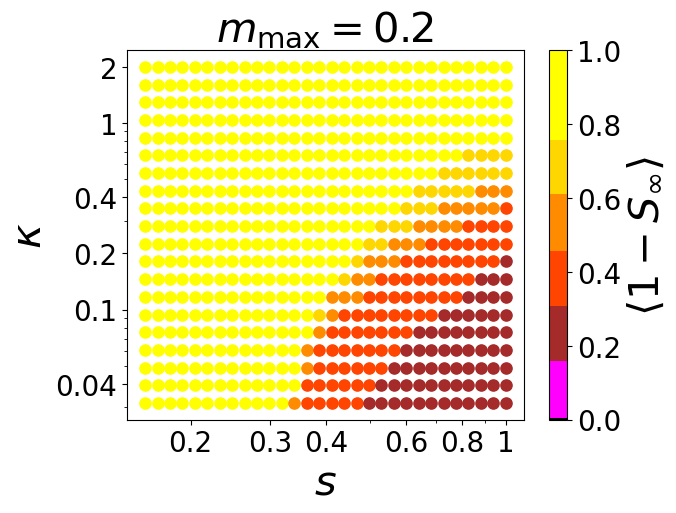

In [29]:
PlotSIRSsm_HeatmapOfLimCycleMean_s_vs_fraction()
plt.savefig(f'img/SIRSsm_HeatmapOfLimCycleMean1-S_s_vs_fraction_ForPaper.pdf', bbox_inches='tight')
plt.show()

#### Flattened Colors:

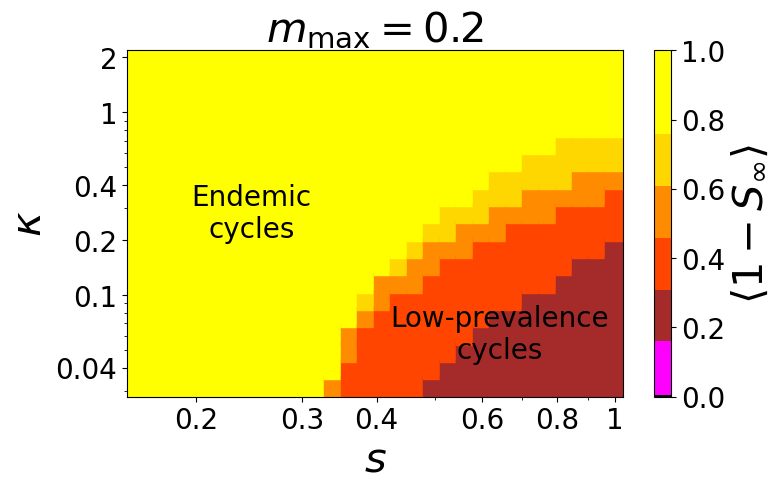

In [30]:
PlotSIRSsm_HeatmapOfLimCycleMean_s_vs_fraction(flattenedColors=True)

#scatter the word endemic cycles on the lower left of the plot and the words low-infection cycles on the upper right of the plot
plt.text(s_values[7], fraction[10], 'Endemic\ncycles', color='k', fontsize=20, ha='center', va='center')
plt.text(s_values[22], fraction[3], 'Low-prevalence\ncycles', color='k', fontsize=20, ha='center', va='center')

plt.savefig(f'img/SIRSsm_HeatmapOfLimCycleMean1-S_s_vs_fraction_flattenedColors_ForPaper.pdf', bbox_inches='tight')
plt.show()

### Heatmap For Paper: mmax vs Ratefraction

In [5]:
Years_evol = 100
p['s'] = 0.25

########### AC or decay rate METHOD ###########
# decay rate method
MethodLabel = "_checkedwithAmplDecay"

# # AC Method
# MethodLabel = ""

################## Colormap #######################
# SEBA SAYS THIS ONE IS NOT GOOD FOR BLIND PEOPLE 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
cm_spring = cm.get_cmap("spring")
Val1 = 0.158
Val2 = 0.908
ColStep = (Val2-Val1)/5
colors = [
    (0.0, 'k'), (0.001, 'k'), (0.001, cm_spring(0)), (Val1, cm_spring(0)),
    (Val1, 'grey'), (Val1+ColStep, 'grey'), (Val1+ColStep, 'grey'), (Val1+ColStep*2, 'grey'), 
    (Val1+ColStep*2, 'darkorange'), (Val1+ColStep*3, 'darkorange'), (Val1+ColStep*3, 'gold'), (Val1+ColStep*4, 'gold'), 
    (Val1+ColStep*4, 'yellow'), (Val2, 'yellow'), (Val2, 'yellow'), (1, 'yellow')
] # changed last colors from gold/yellow to yellow/yellow (see 'Non matching Heatmap' chapter in Symmetric Model +sm.ipynb)
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# # COLORBLIND FRIENDLY VERSION (BUT UGLY COLORS)
# from matplotlib.colors import LinearSegmentedColormap
# Col1 = '#70362D'
# Col2 = '#8D475B'
# Col3 = 'grey'#'#916690'
# Col4 = 'grey'#'#728DBB'
# Col5 = '#2EB3CB'
# Col6 = '#15D5B8'
# Col7 = '#80EF8F'
# Col8 = '#E6FE67'
# Val1 = 0.133
# Val2 = 0.908
# ColStep = (Val2-Val1)/6
# colors = [
#     (0.0, 'k'), (0.001, 'k'), (0.001, Col1), (Val1-ColStep/8, Col1),
#     (Val1-ColStep/8, Col2), (Val1+ColStep, Col2), (Val1+ColStep, Col3), (Val1+ColStep*2, Col3), 
#     (Val1+ColStep*2, Col4), (Val1+ColStep*3, Col4), (Val1+ColStep*3, Col5), (Val1+ColStep*4, Col5), 
#     (Val1+ColStep*4, Col6), (Val2-ColStep,Col7), (Val2-ColStep, Col7), (Val2, Col8), (1, Col8)
# ]
# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

C:\Users\PCUser\AppData\Local\Temp\ipykernel_23404\1627721348.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm_spring = cm.get_cmap("spring")


In [6]:
def PlotSIRSsm_HeatmapOfLimCycleMean_mmax_vs_fraction_forPaper(AddedLabel, MethodLabel, mmax, fraction, AmplDec_thresh = 1e-5, flattenedColors=False): # change AmplDec_thresh for appropriate visualization when using Amplitude decay method
    
    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 15
    plt.rcParams['axes.titlesize'] = 30

    if flattenedColors:
        fig, ax = plt.subplots(figsize=(8,4)) 
        ax.set_aspect(4/9) 
        LC_marker = 's'
    else:
        ax = plt.gca()
        LC_marker = 'o'

    if(flattenedColors == False): 
        Peaks = np.load(f"Data/DataSIRSsm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy")
        for mmax_idx in range(len(mmax)):
            for k in range(len(fraction)):
                if(MethodLabel == ""):
                    # FOR CASE WITH AUTOCORRELATIONS:
                    if(Peaks[mmax_idx,k,1] == -1): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker='x',s=65) # ERROR
                    elif(Peaks[mmax_idx,k,1] == 1): use_marker = LC_marker # its a limit cycle
                    elif(Peaks[mmax_idx,k,1] == 0): use_marker = '$F$' # its a fixpoint
                    elif(Peaks[mmax_idx,k,1] == 2): use_marker = '$o$' #'$C$' # its not periodic
                    else: print('ERROR: invalid classification')

                elif(MethodLabel == "_checkedwithAmplDecay"):
                    # FOR CASE WITH AMPLITUDE DECAY:
                    AmplDec_FOI = Peaks[mmax_idx, k, 1]
                    AmplDec_Rinf = Peaks[mmax_idx, k, 2]

                    if(Peaks[mmax_idx,k,1] == -1): use_marker = 'x'
                    elif(AmplDec_FOI == -100 or AmplDec_Rinf == -100): use_marker = '$F$' # its a fixpoint
                    elif(np.abs(AmplDec_FOI) < AmplDec_thresh or np.abs(AmplDec_Rinf) < AmplDec_thresh): use_marker = LC_marker # its a limit cycle
                    elif(AmplDec_FOI < -AmplDec_thresh and AmplDec_Rinf < -AmplDec_thresh): use_marker = '.' # infinitesimal limit cycles (looks like slowly converging fixpoint)
                    elif(AmplDec_FOI > AmplDec_thresh or AmplDec_Rinf > AmplDec_thresh): use_marker = '$D$' # diverging
                    else: use_marker = '$?$' # inconclusive

                    if(use_marker=='.'): use_marker = LC_marker # treat slowly converging LC as LC

                if(Peaks[mmax_idx,k,0] == 0): ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker=use_marker,s=65)
                else: cax = ax.scatter(mmax[mmax_idx],fraction[k],c=Peaks[mmax_idx,k,0],cmap=cmap,vmin=0,vmax=Vmax,marker=use_marker,s=65)
        ax.set_yticks([.1,.2,.4,1,2,3],labels=[.1,.2,.4,1,2,3])
    if flattenedColors:
        LimitCycleTraj = np.load(f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax_ForPaper_skip10steps.npy')
        chaotic_combinations = [(29,8),(31,2),(35,0),(35,1),(35,2),(36,2),(36,3),(36,4),(37,3),(37,3),(37,5),(38,4),(38,5),(38,6),(39,5),(39,6)] # CONTINUE HEREEE: UPDATE THIS FOR NEW RANGES
        for mmax_idx in range(len(mmax)):
            for k in range(len(fraction)):
                if(mmax_idx == 31 and k == 3): # one error due to tolerances not lowered. Traj has been checked in cell named 'check specific parameter combinations where simul failed'
                    cax = ax.scatter(mmax[mmax_idx],fraction[k],c=np.mean(LimitCycleTraj[mmax_idx+1,k,1,:]),cmap=cmap,vmin=0,vmax=Vmax,marker=LC_marker,s=120) # for this one use adjecent value
                else: cax = ax.scatter(mmax[mmax_idx],fraction[k],c=np.mean(LimitCycleTraj[mmax_idx,k,1,:]),cmap=cmap,vmin=0,vmax=Vmax,marker=LC_marker,s=120)
        for mmax_idx in range(len(mmax)): # draw C's for chaotic combinations on top of colored markers
            for k in range(len(fraction)):        
                if (mmax_idx,k) in chaotic_combinations:
                    ax.scatter(mmax[mmax_idx],fraction[k],c='k',marker='$C$',s=55, label='chaos' if (mmax_idx,k)==chaotic_combinations[0] else None)
        ax.set_yticks([.1,.2,.3,.5,1,2,3],labels=[.1,.2,.3,.5,1,2,3])
    ax.set_xlabel(r'$m_{\rm max}$')
    ax.set_ylabel(r'$\kappa$')
    s_value = p['s']
    ax.set_title(fr'$s=${s_value}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([.1,.2,.3,.4,.6,.8,1],labels=[.1,.2,.3,.4,.6,.8,1])
    if flattenedColors:
        ax.set_ylim(min(fraction)-(fraction[1]-fraction[0])/2, max(fraction)+(fraction[-1]-fraction[-2])/2)
        ax.set_xlim(min(mmax)-(mmax[1]-mmax[0])/2, max(mmax)+(mmax[-1]-mmax[-2])/2)
    plt.colorbar(cax, label=r'$\langle 1-S_\infty\rangle$')

    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20

#### First Check whether LC or FPs with only 100 years evol (frac = [10^-0.7, 3]):

In [11]:
########### Plotting range ##############

#more extended logspace in kappa + save mean NOT max
AddedLabel = "_ForPaper"
Vmax = 1
mmax = np.logspace(-1,0,40)
fraction = np.logspace(-0.7,np.log10(3),20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.


In [33]:
if(MethodLabel == ""):
    Peaks = np.empty((len(mmax),len(fraction),2)) # FOR CASE WITH AUTOCORRELATIONS: # last "2" is [1-SValue, Type] to know whether its a limit cycle (Type=1), FP (Type=0) or chaotic (Type=2)
elif(MethodLabel == "_checkedwithAmplDecay"):
    Peaks = np.empty((len(mmax),len(fraction),3)) # FOR CASE WITH AMPLITUDE DECAY: last "3" is [1-SValue, PeriodicityValueFOI, PeriodicityValueRinf] to know whether its a limit cycle or FP etc

SetInCondfullSIRS(epsi, p, InInfComp)

for mmax_idx in range(len(mmax)):
    for k in range(len(fraction)):
        print('computing mmax =',mmax[mmax_idx],'and fraction =',fraction[k])

        #if(mmax[mmax_idx]<0.7): Years_evol = 25 # here yellow FPs which converge fast
        #else: 
        Years_evol = 100

        SetTolerances_for_kappa_mmax(mmax[mmax_idx], fraction[k], p)

        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] 
        p['tmax'] = Years_evol*360 
        cut = int(p['tmax']/p['stepsize']*7/10)

        
        p['mmax'] = mmax[mmax_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax[mmax_idx] * m.m_normalized(H)
            FOI = p['alpha'] * SoftPlus*SF

            #peak_idces, _ = scp.signal.find_peaks(1-S)
            if(MethodLabel == ""):
                ######## CHECK WITH AUTOCORRELATIONS (Problem: LC and slowly conv FPs undistinguishable) ##########
                #if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                if(is_Fixpoint(FOI) or is_Fixpoint(1-S)): 
                    Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                    Peaks[mmax_idx, k, 1] = 0
                    continue
                else: #if(max(1-S)-min(1-S)>.01):

                    # # check if chaotic 1:
                    # found_NotPeriodic = False
                    # FOI_middlevalue = np.mean((np.max(FOI),np.min(FOI)))

                    # counter = 0
                    # for i in range(len(FOI)-1):
                    #     if(FOI[i]<FOI_middlevalue and FOI[i+1]>=FOI_middlevalue):
                    #         if(counter==0): 
                    #             upper_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==1): 
                    #             lower_ref = 1-S[i]
                    #             counter += 1
                    #         if(counter==2 and upper_ref-(1-S[i])>0.001 and 1-S[i]-lower_ref>0.001): # chaotic
                    #             found_NotPeriodic = True
                    #             break

                    # # check if chaotic 2:
                    # import nolds
                    # LE = nolds.lyap_r(1-S)
                    # if(LE>0): # chaotic
                    #     found_NotPeriodic = True

                    #check if chaotic 3:
                    if(CheckIfPeriodic(FOI) and CheckIfPeriodic(1-S)):
                        found_NotPeriodic = False
                    else:
                        found_NotPeriodic = True

                            
                    if(found_NotPeriodic): # not periodic
                        Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 2
                        continue
                    else: # limit cycle
                        Peaks[mmax_idx, k, 0] = np.mean(1-S) #np.max([1-S[idx] for idx in peak_idces])
                        Peaks[mmax_idx, k, 1] = 1

            elif(MethodLabel == "_checkedwithAmplDecay"):
                ################ CHECK WITH PEAK AMPLITUDE DECAY  ###################
                if(is_Fixpoint(1-S, checkOnlyLastValues=True) == True): # check if FP first
                    Peaks[mmax_idx, k, 0] = np.mean(1-S)
                    Peaks[mmax_idx, k, 1] = -100
                    Peaks[mmax_idx, k, 2] = -100
                else:
                    Peaks[mmax_idx, k, 0] = np.mean(1-S)
                    Peaks[mmax_idx, k, 1] = amplitude_decay(FOI)
                    Peaks[mmax_idx, k, 2] = amplitude_decay(1-S)
        
        except RuntimeError as errormessage:
            print(errormessage)
            Peaks[mmax_idx, k, 0] = -1
            Peaks[mmax_idx, k, 1] = -1
            pass

p['mmax'] = 0.2
p['tolerances'] = [1e-10, 1e-13]

np.save(f'Data/DataSIRSsm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy', Peaks)

computing mmax = 0.1 and fraction = 0.03162277660168379


KeyboardInterrupt: 

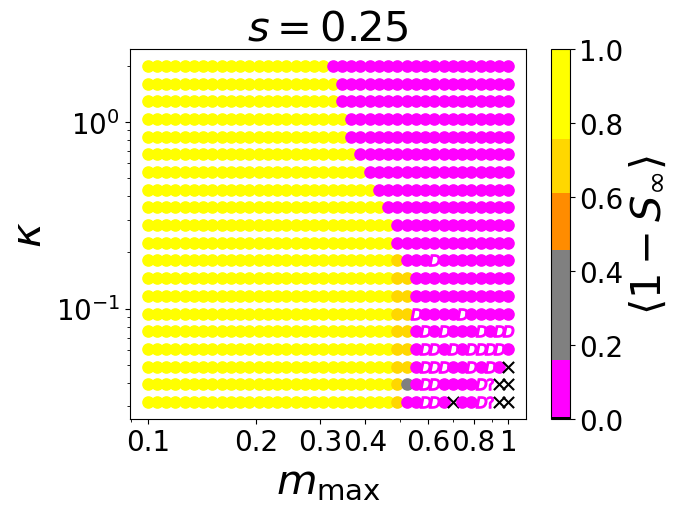

In [34]:
PlotSIRSsm_HeatmapOfLimCycleMean_mmax_vs_fraction_forPaper(AddedLabel, MethodLabel, mmax, fraction)
plt.savefig(f'img/SIRSsm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.pdf', bbox_inches='tight')
plt.show()

<font color='red'> Not evolved for long enough

mmax= 0.9426684551178852 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


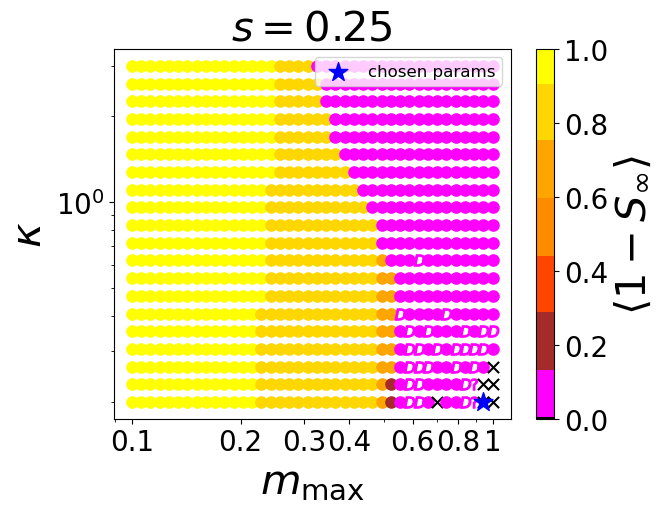

tolerances lowered for kappa = 0.19952623149688797 and mmax = 0.9426684551178852


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[5.00000000e-03 5.38019340e-03 5.76977238e-03 ... 1.73700265e-09
 1.72831249e-09 1.71966585e-09]
[2.82523194e-09 2.81110146e-09 2.79704160e-09 2.78305190e-09
 2.76913226e-09 2.75528211e-09 2.74150125e-09 2.72778933e-09
 2.71414591e-09 2.70057077e-09 2.68706335e-09 2.67362354e-09
 2.66025091e-09 2.64694533e-09 2.63370603e-09 2.62053290e-09
 2.60742572e-09 2.59438404e-09 2.58140775e-09 2.56849608e-09
 2.55564903e-09 2.54286625e-09 2.53014742e-09 2.51749210e-09
 2.50489995e-09 2.49237087e-09 2.47990450e-09 2.46750032e-09
 2.45515819e-09 2.44287779e-09 2.43065879e-09 2.41850084e-09
 2.40640374e-09 2.39436704e-09 2.38239051e-09 2.37047382e-09
 2.35861686e-09 2.34681896e-09 2.33508024e-09 2.32340025e-09
 2.31177844e-09 2.30021480e-09 2.28870900e-09 2.27726060e-09
 2.26586949e-09 2.25453545e-09 2.24325802e-09 2.23203700e-09
 2.22087204e-09 2.20976282e-09 2.19870921e-09 2.18771090e-09
 2.17676754e-09 2.16587881e-09 2.15504459e-09 2.14426465e-09
 2.13353846e-09 2.12286588e-09 2.11224671e-09 2.1

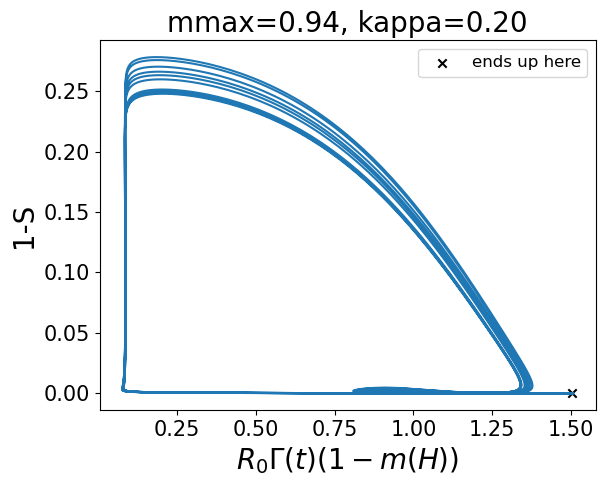

c:\Users\PCUser\Documents\GitHub\Main\MA\CODING\Symmetric Model +sm\..\Tools.py:150: RuntimeWarning: invalid value encountered in log
  coeff = np.polyfit(t, np.log(peak_vals), 1)


ERROR in amplitude decay calculation: SVD did not converge in Linear Least Squares
mmax= 1.0 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


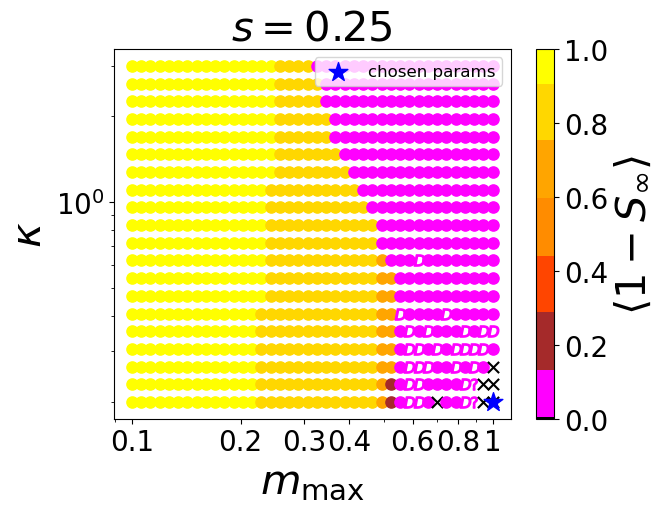

tolerances lowered for kappa = 0.19952623149688797 and mmax = 1.0


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[0.005      0.0053803  0.00576999 ... 0.07279764 0.07515469 0.07759319]
[0.00477109 0.00489566 0.00502361 0.00515502 0.00529    0.00542866
 0.00557109 0.00571741 0.00586774 0.00602217 0.00618085 0.00634388
 0.00651141 0.00668355 0.00686045 0.00704224 0.00722908 0.00742111
 0.00761849 0.00782138 0.00802994 0.00824434 0.00846477 0.00869139
 0.00892441 0.00916402 0.00941042 0.00966382 0.00992444 0.01019249
 0.01046821 0.01075185 0.01104364 0.01134385 0.01165274 0.01197059
 0.01229768 0.01263431 0.01298079 0.01333743 0.01370455 0.01408252
 0.01447167 0.01487237 0.01528501 0.01570998 0.01614769 0.01659856
 0.01706304 0.01754159 0.01803467 0.0185428  0.01906647 0.01960622
 0.02016261 0.02073621 0.02132762 0.02193746 0.02256638 0.02321504
 0.02388415 0.02457443 0.02528664 0.02602156 0.02678001 0.02756283
 0.02837091 0.02920517 0.03006655 0.03095606 0.03187472 0.0328236
 0.03380383 0.03481657 0.035863   0.0369444  0.03806206 0.03921733
 0.04041162 0.04164638 0.04292312 0.04424341 0.04560887 0.

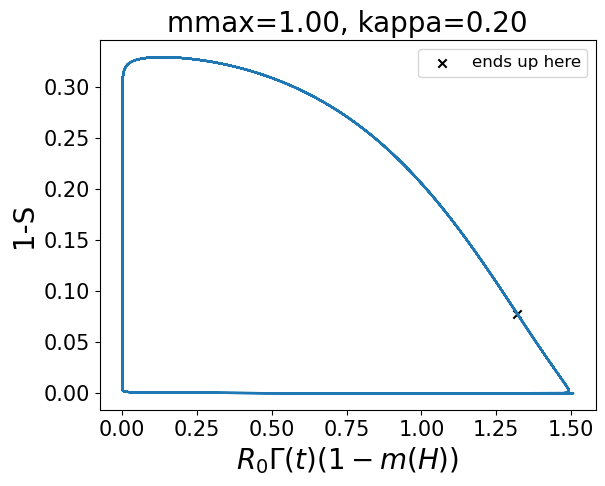

c:\Users\PCUser\Documents\GitHub\Main\MA\CODING\Symmetric Model +sm\..\Tools.py:150: RuntimeWarning: invalid value encountered in log
  coeff = np.polyfit(t, np.log(peak_vals), 1)


ERROR in amplitude decay calculation: SVD did not converge in Linear Least Squares
mmax= 0.9426684551178852 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


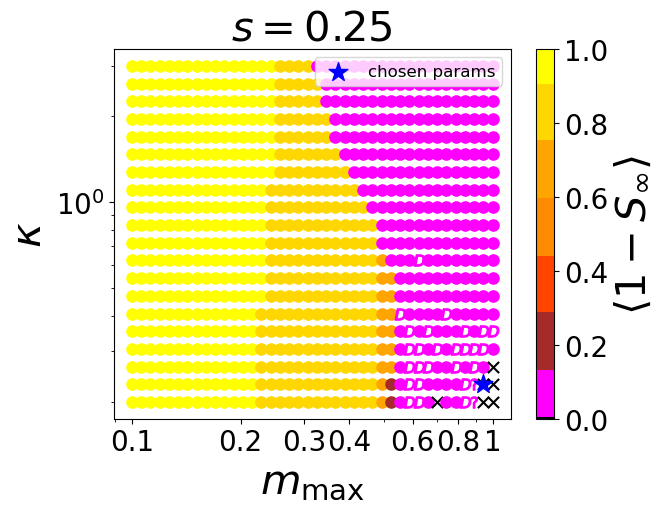

tolerances lowered for kappa = 0.2301196740739713 and mmax = 0.9426684551178852


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[5.00000000e-03 5.32911433e-03 5.66524951e-03 ... 3.02891046e-12
 3.12416759e-12 3.22164517e-12]
[-7.45847828e-13 -7.34745598e-13 -7.23199278e-13 -7.11430914e-13
 -6.99440506e-13 -6.87228052e-13 -6.74571510e-13 -6.61914967e-13
 -6.48592291e-13 -6.35269615e-13 -6.21724894e-13 -6.07736084e-13
 -5.93525229e-13 -5.78870285e-13 -5.63549207e-13 -5.48450174e-13
 -5.32685007e-13 -5.16919840e-13 -5.00488540e-13 -4.83613150e-13
 -4.66515715e-13 -4.49196236e-13 -4.31210623e-13 -4.13225010e-13
 -3.94573263e-13 -3.75477427e-13 -3.55937502e-13 -3.35953487e-13
 -3.15525384e-13 -2.94875235e-13 -2.73336909e-13 -2.51576537e-13
 -2.29594121e-13 -2.06723527e-13 -1.83630888e-13 -1.59650071e-13
 -1.35225164e-13 -1.10356169e-13 -8.48210391e-14 -5.90638649e-14
 -3.26405569e-14 -5.32907052e-15  2.24265051e-14  5.07371922e-14
  7.98250355e-14  1.09356968e-13  1.39777079e-13  1.70641279e-13
  2.02393657e-13  2.34701147e-13  2.67896816e-13  3.01758618e-13
  3.36397576e-13  3.71702669e-13  4.07895939e-13  4.448663

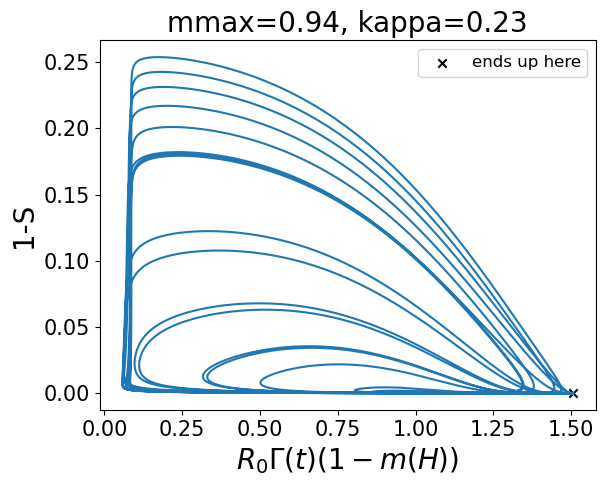

c:\Users\PCUser\Documents\GitHub\Main\MA\CODING\Symmetric Model +sm\..\Tools.py:150: RuntimeWarning: invalid value encountered in log
  coeff = np.polyfit(t, np.log(peak_vals), 1)


ERROR in amplitude decay calculation: SVD did not converge in Linear Least Squares
mmax= 1.0 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


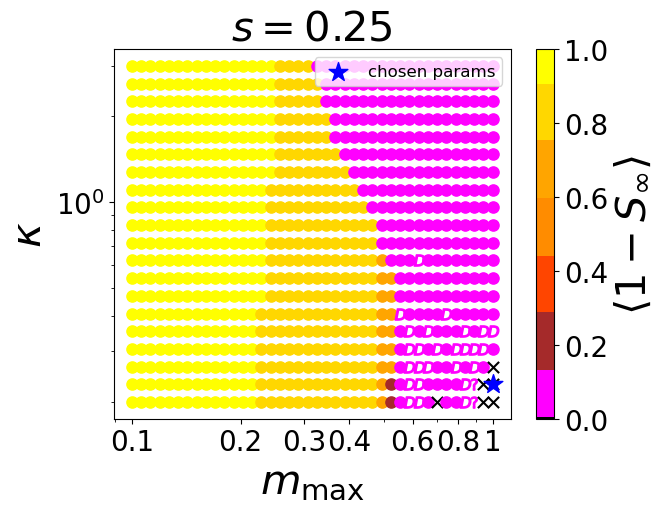

tolerances lowered for kappa = 0.2301196740739713 and mmax = 1.0


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


at mmax= 1.0 and Ratefraction= 0.2301196740739713 ERROR: Solver stopped due to negative population.
mmax= 1.0 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


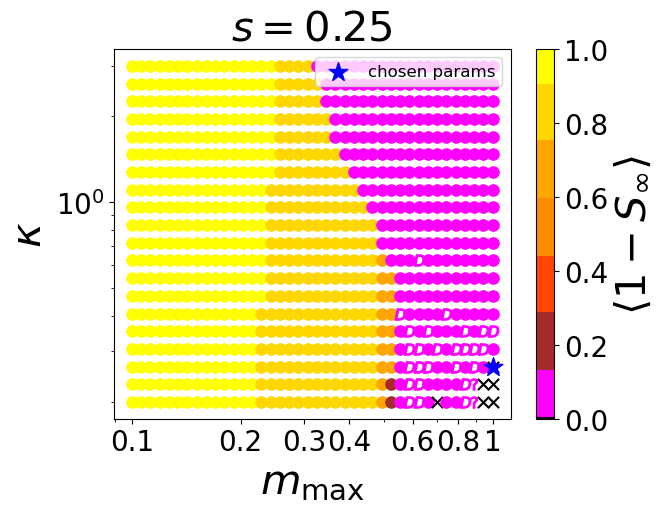

tolerances lowered for kappa = 0.26540402231140575 and mmax = 1.0


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[0.005      0.00528504 0.00557533 ... 0.00276063 0.00281425 0.00286893]
[0.00043592 0.0004442  0.00045263 0.00046123 0.00047    0.00047894
 0.00048805 0.00049733 0.00050679 0.00051644 0.00052627 0.00053629
 0.0005465  0.00055692 0.00056753 0.00057835 0.00058937 0.00060061
 0.00061207 0.00062375 0.00063565 0.00064779 0.00066015 0.00067276
 0.00068561 0.00069871 0.00071207 0.00072568 0.00073956 0.0007537
 0.00076812 0.00078282 0.0007978  0.00081307 0.00082864 0.00084451
 0.00086069 0.00087719 0.000894   0.00091114 0.00092861 0.00094642
 0.00096457 0.00098308 0.00100195 0.00102118 0.00104079 0.00106078
 0.00108115 0.00110193 0.0011231  0.00114469 0.0011667  0.00118914
 0.00121201 0.00123533 0.0012591  0.00128333 0.00130804 0.00133323
 0.00135891 0.00138508 0.00141177 0.00143898 0.00146672 0.001495
 0.00152383 0.00155322 0.00158319 0.00161374 0.00164489 0.00167665
 0.00170903 0.00174204 0.00177569 0.00181    0.00184499 0.00188065
 0.00191702 0.00195409 0.00199189 0.00203043 0.00206973 0.00

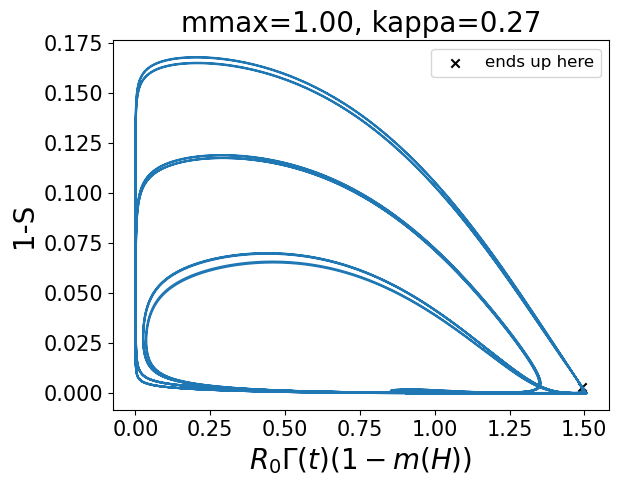

Amplitude decay in FOI 8.209244338870943e-05 % in Rinf: -0.32437565599382284 %
mmax= 0.7017038286703828 fraction= [0.19952623 0.23011967 0.26540402 0.30609853 0.35303275 0.40716342
 0.46959396 0.541597   0.6246403  0.72041667 0.83087846 0.95827742
 1.1052105  1.2746729  1.47011904 1.69553303 1.95550983 2.25534899
 2.60116262 3.        ] [1-S,PeriodicityValueFOI,PVRinf]= [-1.00000000e+000 -1.00000000e+000  6.95190582e-310]
This one was classified as a limit cycle


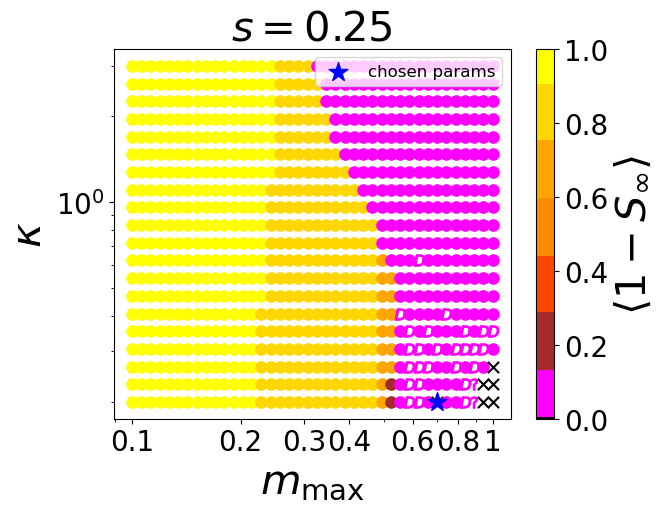

c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[5.00000000e-03 5.37976294e-03 5.76886822e-03 ... 6.93710293e-07
 7.11459780e-07 7.29664178e-07]
[6.05596805e-08 6.20892476e-08 6.36577981e-08 6.52663315e-08
 6.69158727e-08 6.86074733e-08 7.03422116e-08 7.21211938e-08
 7.39455546e-08 7.58164578e-08 7.77350968e-08 7.97026962e-08
 8.17205120e-08 8.37898321e-08 8.59119780e-08 8.80883045e-08
 9.03202021e-08 9.26090964e-08 9.49564499e-08 9.73637626e-08
 9.98325732e-08 1.02364460e-07 1.04961041e-07 1.07623977e-07
 1.10354971e-07 1.13155769e-07 1.16028164e-07 1.18973993e-07
 1.21995140e-07 1.25093539e-07 1.28271174e-07 1.31530077e-07
 1.34872336e-07 1.38300089e-07 1.41815533e-07 1.45420916e-07
 1.49118550e-07 1.52910801e-07 1.56800100e-07 1.60788937e-07
 1.64879868e-07 1.69075513e-07 1.73378562e-07 1.77791772e-07
 1.82317970e-07 1.86960057e-07 1.91721009e-07 1.96603878e-07
 2.01611792e-07 2.06747962e-07 2.12015681e-07 2.17418326e-07
 2.22959361e-07 2.28642337e-07 2.34470899e-07 2.40448784e-07
 2.46579824e-07 2.52867952e-07 2.59317198e-07 2.6

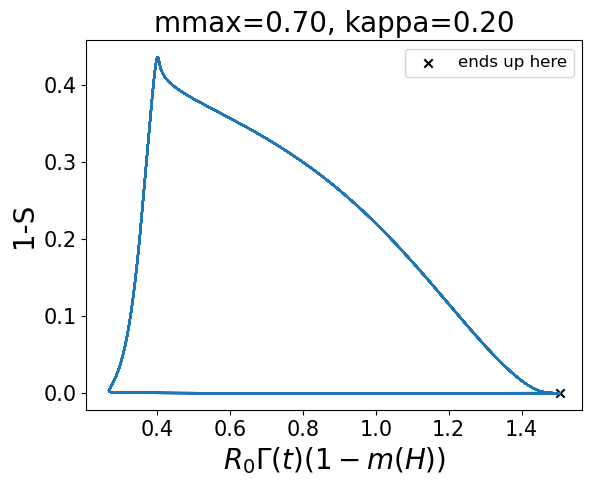

ERROR in amplitude decay calculation: SVD did not converge in Linear Least Squares


c:\Users\PCUser\Documents\GitHub\Main\MA\CODING\Symmetric Model +sm\..\Tools.py:150: RuntimeWarning: invalid value encountered in log
  coeff = np.polyfit(t, np.log(peak_vals), 1)


In [24]:
# check trajectories:
Peaks = np.load(f"Data/DataSIRSsm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction{AddedLabel}{MethodLabel}.npy")

Years_evol = 100 # shrink to 60-100 if alpha=0.09 (init at tipp point), else if alpha=0.12 can do 1000

p['s'] = 0.25

#############################################
# Check by index of Heatmap plot:
mmax_idx_list = [-2,-1,-2,-1,-1,-7]
k_list = [0,0,1,1,2,0]

for example_idx in range(len(mmax_idx_list)):
    mmax_idx = mmax_idx_list[example_idx]
    k = k_list[example_idx]

    frac = fraction[k]

    print('mmax=',mmax[mmax_idx],'fraction=',fraction,'[1-S,PeriodicityValueFOI,PVRinf]=',Peaks[mmax_idx,k])


    if(MethodLabel == ""):
        # FOR CASE WITH AUTOCORRELATIONS:
        if(Peaks[mmax_idx,k,1] == -1): print('This one gave error')
        elif(Peaks[mmax_idx,k,1] == 1): print('This one was classified as a limit cycle')
        elif(Peaks[mmax_idx,k,1] == 0): print('This one was classified as a fixpoint')
        elif(Peaks[mmax_idx,k,1] == 2): print('This one was classified as not periodic')
        else: print('ERROR: invalid classification')

    elif(MethodLabel == "_checkedwithAmplDecay"):
        # FOR CASE WITH AMPLITUDE DECAY:
        AmplDec_thresh = 1e-5 ## chenge this for appropriate visualization
        AmplDec_FOI = Peaks[mmax_idx, k, 1]
        AmplDec_Rinf = Peaks[mmax_idx, k, 2]

        if(AmplDec_FOI == -100 or AmplDec_Rinf == -100): print('This one was classified as a fixpoint')
        elif(np.abs(AmplDec_FOI) < AmplDec_thresh or np.abs(AmplDec_Rinf) < AmplDec_thresh): print('This one was classified as a limit cycle')
        elif(AmplDec_FOI < -AmplDec_thresh and AmplDec_Rinf < -AmplDec_thresh): print('This one was slowly converging to a fixpoint')
        elif(AmplDec_FOI > AmplDec_thresh or AmplDec_Rinf > AmplDec_thresh): print('This one was diverging')
        else: print('This one was inconclusive in classification')

    ##############################################
    PlotSIRSsm_HeatmapOfLimCycleMean_mmax_vs_fraction_forPaper(AddedLabel, MethodLabel, mmax, fraction)
    plt.scatter(mmax[mmax_idx],fraction[k],c='b',marker='*',s=200,label='chosen params')
    plt.legend()
    plt.show()
    #######

    SetTolerances_for_kappa_mmax(mmax[mmax_idx], fraction[k], p)
    p['tolerances'] = [1e-15, 1e-18]

    SetInCondfullSIRS(epsi, p, InInfComp)

    p['gamma'] = .1/frac
    p['alpha'] = .12/frac
    p['nu'] = .01/frac
    p['beta'] = C*p['alpha']
    p['tmax'] = Years_evol*360
    cut = int(p['tmax']/p['stepsize']*7/10)
    p['mmax'] = mmax[mmax_idx]

    try:
        m = model(**p)
        times, Data = m.run()

        # UNCUT PLOTS
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
        SoftPlus_uncut = 1 - p['mmax'] * m.m_normalized(H)

        print(1-S)

        # plt.title('1-m(h)')
        # plt.plot(times/360, SoftPlus_uncut)
        # plt.xlabel('time in years')
        # plt.xticks(rotation=45)
        # plt.show()
        # # print('softplus shape=',SoftPlus.shape,'\ncut=', cut)

        # plt.title('H in [0,1]')
        # plt.plot(times/360, H,label='H')
        # plt.xlabel('time in years')
        # plt.xticks(rotation=45)
        # plt.legend()
        # plt.show()
        # # print('times shape=',times.shape)
        # # print('S shape=',S.shape)
        # # print('tmax/timestep=',p['tmax']/p['stepsize'])

        # CUT PLOTS
        times = times[cut:]
        S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
        SF = m.seasonalforcing(times)
        SoftPlus = 1 - p['mmax'] * m.m_normalized(H)
        FOI = p['alpha'] * SoftPlus*SF

        print(1-S[-100:])
        print('=> is_Fixpoint=',is_Fixpoint(1-S, checkOnlyLastValues=True))

        plt.plot(FOI/p['gamma'], 1-S)
        plt.scatter(FOI[-1]/p['gamma'],1-S[-1],label='ends up here',marker='x',c='k')
        plt.title(f'mmax={mmax[mmax_idx]:.2f}, kappa={fraction[k]:.2f}')
        plt.xlabel(r'$R_0\Gamma(t)(1-m(H))$')
        plt.ylabel('1-S')
        plt.legend()
        plt.show()

        if(MethodLabel == "_checkedwithAmplDecay"):
            try: print('Amplitude decay in FOI', amplitude_decay(FOI), '% in Rinf:', amplitude_decay(1-S), '%')
            except Exception as errormessage:
                print("ERROR in amplitude decay calculation:", errormessage)
                pass
        # plt.plot(FOI_ac, label='FOI ac')
        # plt.legend()
        # plt.show()

        # plt.plot(Rinf_ac, label='Rinf ac')
        # plt.legend()
        # plt.show()

    except RuntimeError as errormessage:
        print("at mmax=",p['mmax'],"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

    p['mmax'] = 0.2
    p['tolerances'] = [1e-10, 1e-13]

tolerances lowered for kappa = 0.12 and mmax = 0.95


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


[0.005      0.00563733 0.00630126 ... 0.01798424 0.01887551 0.01981653]
[0.00026642 0.00027779 0.00028966 0.00030204 0.00031494 0.00032841
 0.00034245 0.0003571  0.00037239 0.00038833 0.00040496 0.00042231
 0.0004404  0.00045928 0.00047898 0.00049953 0.00052096 0.00054333
 0.00056666 0.00059101 0.00061641 0.00064291 0.00067057 0.00069943
 0.00072954 0.00076096 0.00079375 0.00082797 0.00086367 0.00090094
 0.00093984 0.00098043 0.0010228  0.00106702 0.00111318 0.00116136
 0.00121166 0.00126417 0.00131899 0.00137621 0.00143596 0.00149835
 0.00156349 0.00163151 0.00170254 0.00177672 0.00185419 0.00193511
 0.00201962 0.00210791 0.00220013 0.00229648 0.00239714 0.00250232
 0.00261223 0.00272708 0.00284712 0.00297258 0.00310373 0.00324083
 0.00338417 0.00353404 0.00369077 0.00385468 0.00402613 0.00420548
 0.00439311 0.00458945 0.00479491 0.00500996 0.00523507 0.00547075
 0.00571754 0.005976   0.00624674 0.00653039 0.00682761 0.00713914
 0.00746571 0.00780813 0.00816725 0.00854397 0.00893925 0

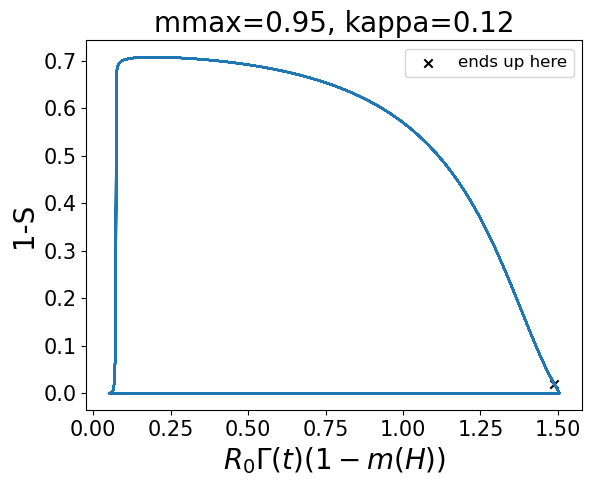

In [35]:
# check trajectories of any mmax and fraction combination

Years_evol = 200 # shrink to 60-100 if alpha=0.09 (init at tipp point), else if alpha=0.12 can do 1000
p['s'] = 0.25

#############################################
mmax_value = 0.95
frac = 0.12
#############################################

SetTolerances_for_kappa_mmax(mmax_value, frac, p)
p['tolerances'] = [1e-15, 1e-18]

SetInCondfullSIRS(epsi, p, InInfComp)

p['gamma'] = .1/frac
p['alpha'] = .12/frac
p['nu'] = .01/frac
p['beta'] = C*p['alpha']
p['tmax'] = Years_evol*360
cut = int(p['tmax']/p['stepsize']*7/10)
p['mmax'] = mmax_value

try:
    m = model(**p)
    times, Data = m.run()

    # UNCUT PLOTS
    S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data
    SoftPlus_uncut = 1 - p['mmax'] * m.m_normalized(H)

    print(1-S)

    # plt.title('1-m(h)')
    # plt.plot(times/360, SoftPlus_uncut)
    # plt.xlabel('time in years')
    # plt.xticks(rotation=45)
    # plt.show()
    # # print('softplus shape=',SoftPlus.shape,'\ncut=', cut)

    # plt.title('H in [0,1]')
    # plt.plot(times/360, H,label='H')
    # plt.xlabel('time in years')
    # plt.xticks(rotation=45)
    # plt.legend()
    # plt.show()
    # # print('times shape=',times.shape)
    # # print('S shape=',S.shape)
    # # print('tmax/timestep=',p['tmax']/p['stepsize'])

    # CUT PLOTS
    times = times[cut:]
    S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
    SF = m.seasonalforcing(times)
    SoftPlus = 1 - p['mmax'] * m.m_normalized(H)
    FOI = p['alpha'] * SoftPlus*SF

    print(1-S[-100:])
    print('=> is_Fixpoint=',is_Fixpoint(1-S, checkOnlyLastValues=True))

    plt.plot(FOI/p['gamma'], 1-S)
    plt.scatter(FOI[-1]/p['gamma'],1-S[-1],label='ends up here',marker='x',c='k')
    plt.title(f'mmax={p["mmax"]:.2f}, kappa={frac:.2f}')
    plt.xlabel(r'$R_0\Gamma(t)(1-m(H))$')
    plt.ylabel('1-S')
    plt.legend()
    plt.show()


    # plt.plot(Rinf_ac, label='Rinf ac')
    # plt.legend()
    # plt.show()

except RuntimeError as errormessage:
    print("at mmax=",p['mmax'],"and Ratefraction=",fraction[k],"ERROR:", errormessage)
    pass

p['mmax'] = 0.2
p['tolerances'] = [1e-10, 1e-13]

#### Now check with 1000 years the real shape (frac = [0.1,3]):

In [35]:
########### Plotting range ##############

#more extended logspace in kappa + save mean NOT max
AddedLabel = "_ForPaper_skip10steps"
Vmax = 1
mmax = np.logspace(-1,0,40)
fraction = np.logspace(-1,np.log10(3),20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.

In [ ]:
Years_evol_default = 1000
p['tmax'] = Years_evol_default*360 

p['s'] = 0.25
cut_default = int(p['tmax']/p['stepsize']*9/10)
cut = cut_default

p['reduced_output'] = True

#############################################

skip_steps = 10
time_steps = int(((p['tmax']/p['stepsize'])-cut)/skip_steps)

LimitCycleTraj = np.zeros((len(mmax),int(len(fraction)),2,time_steps)) # "2" is [FOI, Rinfty], last one is for the timeevolution of FOI and Rinf

# Look for checkpoint file
checkpoint_path = f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}_checkpoint_deleteifworks.npy'
if os.path.exists(checkpoint_path):
    LimitCycleTraj_checkpoint = np.load(checkpoint_path)
    print('Checkpoint found!')
    use_checkpoint = True
else: 
    print('No checkpoint found...')
    use_checkpoint = False

# Look for finished file
finished_path = f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}.npy'
if os.path.exists(finished_path):
    LimitCycleTraj_finished = np.load(finished_path)
    print('Finished file found!')
else: print('No finished file found...')

for k in range(len(fraction)):
    for mmax_idx in range(len(mmax)):
        
        # Read from checkpoint file to recompute uncomputed combinations '0'
        if(use_checkpoint==True and np.any(LimitCycleTraj_checkpoint[mmax_idx,k,0,:] != 0)):
            print('Already computed mmax=',mmax[mmax_idx],'and fraction=',fraction[k],', loading from checkpoint...')
            LimitCycleTraj[mmax_idx,k] = LimitCycleTraj_checkpoint[mmax_idx,k]
            continue
        # Read from actual file to recompute failed combinations due to Runtimerror (negative pop) '-1': Try these combinations for less tmax
        elif(os.path.exists(finished_path) and np.any(LimitCycleTraj_finished[mmax_idx,k,0,:] != -1)):
            print('Already computed mmax=',mmax[mmax_idx],'and fraction=',fraction[k],', loading from finished file...')
            LimitCycleTraj[mmax_idx,k] = LimitCycleTraj_finished[mmax_idx,k]
            continue
        elif(os.path.exists(finished_path) and np.all(LimitCycleTraj_finished[mmax_idx,k,0,:] == -1)):
            Years_evol_new = 200 ############### LOWER FROM 1000 -> 500 --> 300 --> 200 --> 100 to get rest of Trajectories ########### # basically reduces transient time to prevent numerical instabilities
            cut_new = int(cut-(Years_evol_default-Years_evol_new)*360/p['stepsize'])
            cut = cut_new
            print('Already computed mmax=',mmax[mmax_idx],'and fraction=',fraction[k],', but it gave error, recomputing at for only',Years_evol_new,'years...')
            print('New saved trajectory after cut is as long as default:',int((Years_evol_default*360/p['stepsize'])-cut_default)==int((Years_evol_new*360/p['stepsize'])-cut_new))
            p['tmax'] = Years_evol_new*360 
            pass

        frac = fraction[k]
        p['mmax'] = mmax[mmax_idx]

        SetInCondfullSIRS(epsi, p, InInfComp)

        p['gamma'] = .1/frac
        p['alpha'] = .12/frac
        p['nu'] = .01/frac
        p['beta'] = C*.12/frac

        SetTolerances_for_kappa_mmax(p['mmax'], fraction[k], p)

        try:
            m = model(**p)
            times,S,H = m.run()
            times,S,H = times[cut:], S[cut:], H[cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - p['mmax'] * m.m_normalized(H)
            FOI = p['alpha'] * SoftPlus*SF

            time_indices = range(0, len(FOI), skip_steps)

            LimitCycleTraj[mmax_idx,k,0] = FOI[time_indices]
            LimitCycleTraj[mmax_idx,k,1] = 1-S[time_indices]

        except RuntimeError as errormessage:
            print("at mmax=",p['mmax'],"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            LimitCycleTraj[mmax_idx,k] = np.full((2,time_steps), -1)
            pass
        
        cut = cut_default
        p['mmax'] = 0.2
        p['tolerances'] = [1e-10, 1e-13]
        p['tmax'] = Years_evol_default*360 
        print(mmax_idx+1,'/',len(mmax))
        np.save(f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}_checkpoint_deleteifworks.npy', LimitCycleTraj)
    print('>>>',k+1,'/',len(fraction))

    


np.save(f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}.npy', LimitCycleTraj)

p['reduced_output'] = False

No checkpoint found...
Finished file found!
Already computed mmax= 0.1 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.10608183551394486 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.11253355826007651 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.11937766417144363 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.12663801734674032 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.13433993325989002 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.14251026703029981 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.15117750706156624 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.160371874375133 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.17012542798525887 and fraction= 0.1 , loading from finished file...
Already computed mmax= 0.18047217668271703 a

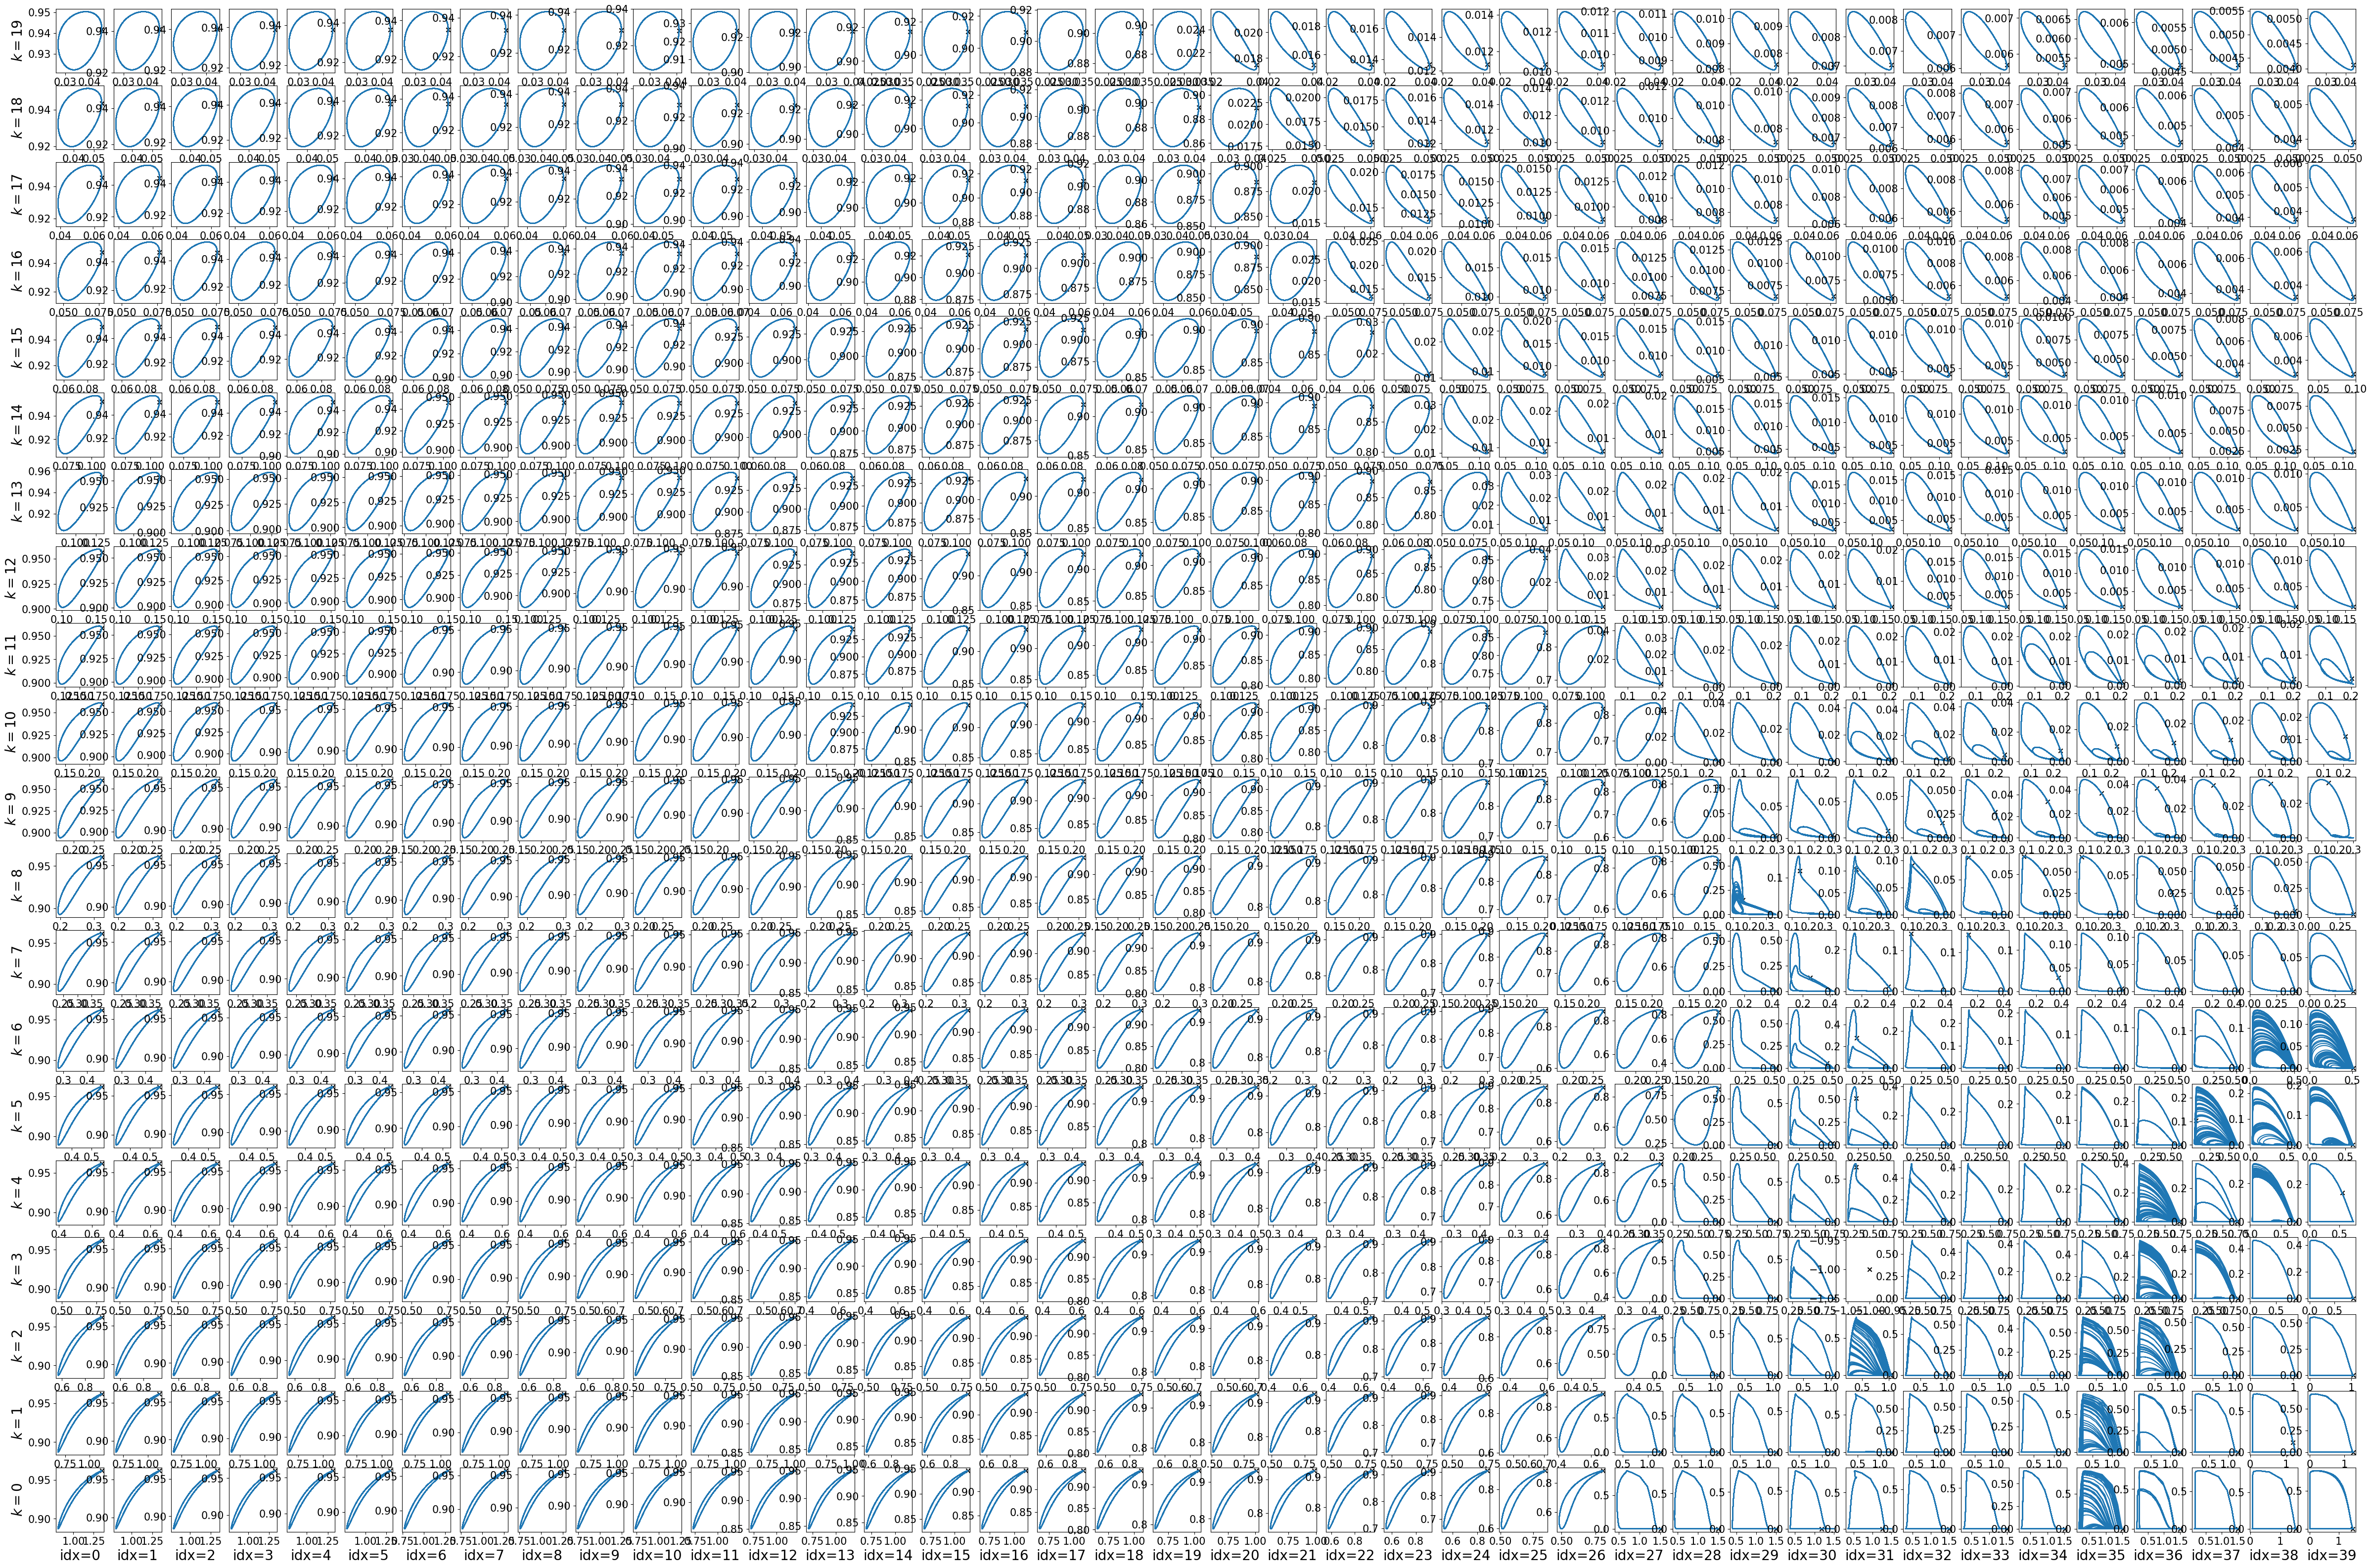

In [22]:
LimitCycleTraj = np.load(f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}.npy')
                           
fig, axes = plt.subplots(len(fraction), len(mmax), figsize=(60,40))

for k in range(len(fraction)):
    for mmax_idx in range(len(mmax)):
        ax = axes[-1-k, mmax_idx]

        FOI = LimitCycleTraj[mmax_idx,k,0]
        Rinf = LimitCycleTraj[mmax_idx,k,1]

        ax.plot(FOI, Rinf)
        ax.scatter(FOI[-1],Rinf[-1],label='ends up here',marker='x',c='k')

        # ax.set_xticks([])
        # ax.set_yticks([])

        if(mmax_idx==0):
            ax.set_ylabel(fr'$k={k}$')
        if(k==0):
            ax.set_xlabel(r'idx=' + fr'{mmax_idx}')


plt.savefig(f'img/SIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}_INSERTtmaxValueOFAttemptHERE.pdf', bbox_inches='tight')
plt.show()

>>> Simulating mmax= 0.6235507341273914 and fraction= 0.1710919876799276 which gave an error before...


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


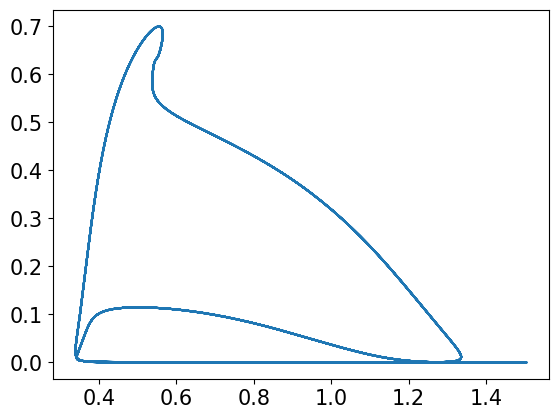

In [ ]:
# check specific parameter combinations where simul failed

Years_evol = 100
p['tmax'] = Years_evol*360 

p['s'] = 0.25
cut = int(p['tmax']/p['stepsize']*7/10)

p['reduced_output'] = True
LimitCycleTraj = np.load(f'Data/DataSIRSsm_LimitCycleTrjectories_forentireBLOCK_fordiff_Ratefractions_mmax{AddedLabel}.npy')

#############################################

skip_steps = 10
time_steps = int(((p['tmax']/p['stepsize'])-cut)/skip_steps)

for k in range(len(fraction)):
    for mmax_idx in range(len(mmax)):
        
        if(LimitCycleTraj[mmax_idx,k,0,0] == -1):
            print('>>> Simulating mmax=',mmax[mmax_idx],'and fraction=',fraction[k],'which gave an error before...')
            frac = fraction[k]
            p['mmax'] = mmax[mmax_idx]

            SetInCondfullSIRS(epsi, p, InInfComp)

            p['gamma'] = .1/frac
            p['alpha'] = .12/frac
            p['nu'] = .01/frac
            p['beta'] = C*.12/frac

            SetTolerances_for_kappa_mmax(p['mmax'], fraction[k], p)
            p['tolerances'] = [1e-15, 1e-18] # do it anyway

            try:
                m = model(**p)
                times,S,H = m.run()
                times,S,H = times[cut:], S[cut:], H[cut:]
                SF = m.seasonalforcing(times)
                SoftPlus = 1 - p['mmax'] * m.m_normalized(H)
                FOI = p['alpha'] * SoftPlus*SF
                plt.plot(FOI/p['gamma'], 1-S)
                plt.show()

            except RuntimeError as errormessage:
                print("at mmax=",p['mmax'],"and Ratefraction=",fraction[k],"ERROR:", errormessage)
                pass
        
        p['mmax'] = 0.2
        p['tolerances'] = [1e-10, 1e-13]

p['reduced_output'] = False

#### Flattened Colors Plot (frac = [0.1,3]):

In [8]:
########### Plotting range ##############

#more extended logspace in kappa + save mean NOT max
AddedLabel = "_ForPaper_skip10steps"
Vmax = 1
mmax = np.logspace(-1,0,40)
fraction = np.logspace(-1,np.log10(3),20) # starting with frac=kappa=.13 > 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.

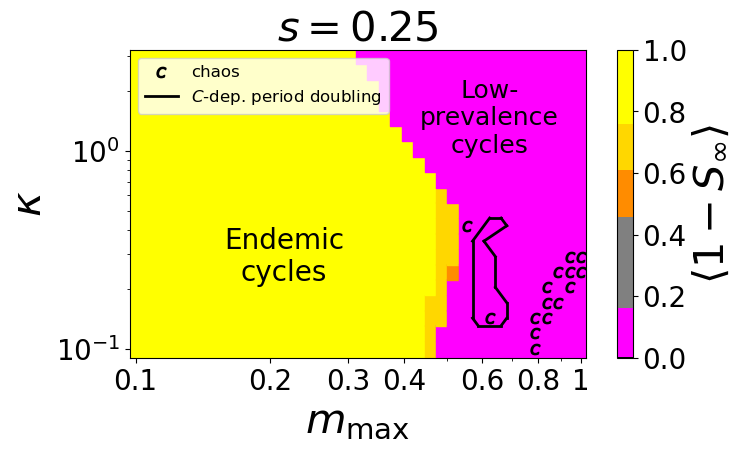

In [13]:
PlotSIRSsm_HeatmapOfLimCycleMean_mmax_vs_fraction_forPaper(AddedLabel, MethodLabel, mmax, fraction, flattenedColors=True)

# turned out first splitting was just part of a normal cascade
# firstSplitting = [[(39,9),(39,9),'right','down'],[(39,9),(34,9),'down','down'],[(34,9),(33,8),'down','down'],[(33,8),(31,8),'down','down'],[(31,8),(29,9),'down','left'],[(29,9),(31,10),'left','up'],[(31,10),(33,10),'up','up'],[(33,10),(34,11),'up','up'],[(34,11),(39,11),'up','up'],[(39,11),(39,11),'up','right']]
# for line_idx in range(len(firstSplitting)):
#     connect_points(plt.gca(), mmax, fraction, firstSplitting[line_idx][0], firstSplitting[line_idx][1], shift=(firstSplitting[line_idx][2], firstSplitting[line_idx][3]), color='gray', label='1st splitting' if line_idx==0 else None)

secondSplitting = [[(30,2),(30,7),'left','left'],[(30,7),(31,8),'left','up'],[(31,8),(32,8),'up','up'],[(32,8),(32,8),'up','right'],[(32,8),(30,7),'right','right'],[(30,7),(31,6),'right','right'],[(31,6),(31,4),'right','right'],[(31,4),(32,3),'right','right'],[(32,3),(32,2),'right','right'],[(32,2),(32,2),'right','down'],[(32,2),(30,2),'down','down'],[(30,2),(30,2),'down','left']]
for line_idx in range(len(secondSplitting)):
    connect_points(plt.gca(), mmax, fraction, secondSplitting[line_idx][0], secondSplitting[line_idx][1], shift=(secondSplitting[line_idx][2], secondSplitting[line_idx][3]), color='k', label=r'$C$-dep. period doubling' if line_idx==0 else None)

plt.text(mmax[13], fraction[6], 'Endemic\ncycles', color='k', fontsize=20, ha='center', va='center')
plt.text(np.mean(mmax[31:32]), fraction[15], 'Low-\nprevalence\ncycles', color='k', fontsize=18, ha='center', va='center')

plt.legend(loc='upper left')
plt.savefig(f'img/SIRSsm_HeatmapOfLimCycleMax1-S_mmax_vs_fraction_{AddedLabel}{MethodLabel}_flattenedAndInclSplittingRegions.pdf', bbox_inches='tight')
plt.show()

### Bifurcation Diagram 1-S for diff mm_max and Ratefrac

#### Simulate:

In [47]:
def SimulatePeaks(Peaks,cut,mmax,mmax_val_idx,counter,p,max_attempts=7):
    attempts = 0
    while attempts <= max_attempts:
        try: 
            m = model(**p)
            times, Data = m.run()
            S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]

            if(np.all(np.array(S[-10:-1])==np.full(9,S[-1]))): 
                Peaks[mmax_val_idx, counter, 0] = mmax
                Peaks[mmax_val_idx, counter, 1] = 1-S[-1]
                counter += 1
            else:
                max_idces, _ = scp.signal.find_peaks(1-S)
                min_idces, _ = scp.signal.find_peaks(S-1)
                Rinf_maxvalues = set([f"{1-S[idx]:.4f}" for idx in max_idces]) # Only keep values that difer by at least 0.001 (set eliminates equal values)
                Rinf_minvalues = set([f"{1-S[idx]:.4f}" for idx in min_idces])

                for Rinf in Rinf_maxvalues:
                    Peaks[mmax_val_idx, counter, 0] = mmax # mmax value is only assigned if there is a peak, else it stays at 0 and is not plotted later
                    Peaks[mmax_val_idx, counter, 1] = Rinf
                    counter += 1
                for Rinf in Rinf_minvalues: 
                    Peaks[mmax_val_idx, counter, 0] = mmax
                    Peaks[mmax_val_idx, counter, 1] = Rinf
                    counter += 1
            p['tmax'] = 40*360
            print(f"Success after {attempts+1} attempts at mmax={mmax}")
            return counter
        except RuntimeError as errormessage: # try again with 20yrs more if it fails
            attempts += 1
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            p['tmax'] += 20*360
            print(f"Trying longer tmax={p['tmax']/360} yrs instead...")
            pass
    
    print('MAX NUMBER OF TMAX INCREASE REACHED')
    return counter

In [50]:
mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

fraction = [.3,.4] # choose which kappa to rerun from [1,.8,.75,.7,.6,.5,.4,.3,.2]

Counter_Max = 0

for k in range(len(fraction)):
    Peaks = np.zeros((len(mmax_valueList),500*10,2))
    for mmax_val_idx, mmax_values in enumerate(mmax_valueList):

        p['gamma'] = .1/fraction[k]
        p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
        p['nu'] = .01/fraction[k]
        p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
        p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
        cut = int(p['tmax']/p['stepsize']*7/10)

        counter = 0
        for mmax in np.linspace(min(mmax_values),max(mmax_values),30):
            p['mmax'] = mmax

            SetTolerances_for_kappa_mmax(mmax, fraction[k], p)
            
            counter = SimulatePeaks(Peaks,cut,mmax,mmax_val_idx,counter,p)
                
            p['tolerances'] = [1e-10,1e-13]
        if(counter>Counter_Max): Counter_Max = counter
        print(mmax_val_idx+1,'/',len(mmax_valueList))
    print('>>>',k+1,'/',len(fraction))
    np.save(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction[k]}.npy', Peaks)

print('Maximum of points on a plot =',Counter_Max)

Success after 1 attempts at mmax=0.4
Success after 1 attempts at mmax=0.40689655172413797
Success after 1 attempts at mmax=0.4137931034482759
Success after 1 attempts at mmax=0.4206896551724138
Success after 1 attempts at mmax=0.42758620689655175
Success after 1 attempts at mmax=0.4344827586206897
Success after 1 attempts at mmax=0.44137931034482764
Success after 1 attempts at mmax=0.4482758620689656
Success after 1 attempts at mmax=0.45517241379310347
Success after 1 attempts at mmax=0.4620689655172414
Success after 1 attempts at mmax=0.46896551724137936
Success after 1 attempts at mmax=0.4758620689655173
Success after 1 attempts at mmax=0.48275862068965525
Success after 1 attempts at mmax=0.48965517241379314
Success after 1 attempts at mmax=0.4965517241379311
Success after 1 attempts at mmax=0.5034482758620691
Success after 1 attempts at mmax=0.5103448275862069
Success after 1 attempts at mmax=0.5172413793103449
Success after 1 attempts at mmax=0.5241379310344828
Success after 1 atte

C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


at mmax= 0.9586206896551724 and Ratefraction= 0.3 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
Success after 2 attempts at mmax=0.9586206896551724
tolerances lowered for kappa = 0.3 and mmax = 0.9655172413793103
Success after 1 attempts at mmax=0.9655172413793103
tolerances lowered for kappa = 0.3 and mmax = 0.9724137931034482
Success after 1 attempts at mmax=0.9724137931034482
tolerances lowered for kappa = 0.3 and mmax = 0.9793103448275862
Success after 1 attempts at mmax=0.9793103448275862
tolerances lowered for kappa = 0.3 and mmax = 0.9862068965517241
at mmax= 0.9862068965517241 and Ratefraction= 0.3 ERROR: Solver stopped due to negative population.
Trying longer tmax=60.0 yrs instead...
Success after 2 attempts at mmax=0.9862068965517241
tolerances lowered for kappa = 0.3 and mmax = 0.993103448275862
Success after 1 attempts at mmax=0.993103448275862
tolerances lowered for kappa = 0.3 and mmax = 1.0
Success after 1 attempts at mmax=1.0


#### Plot:

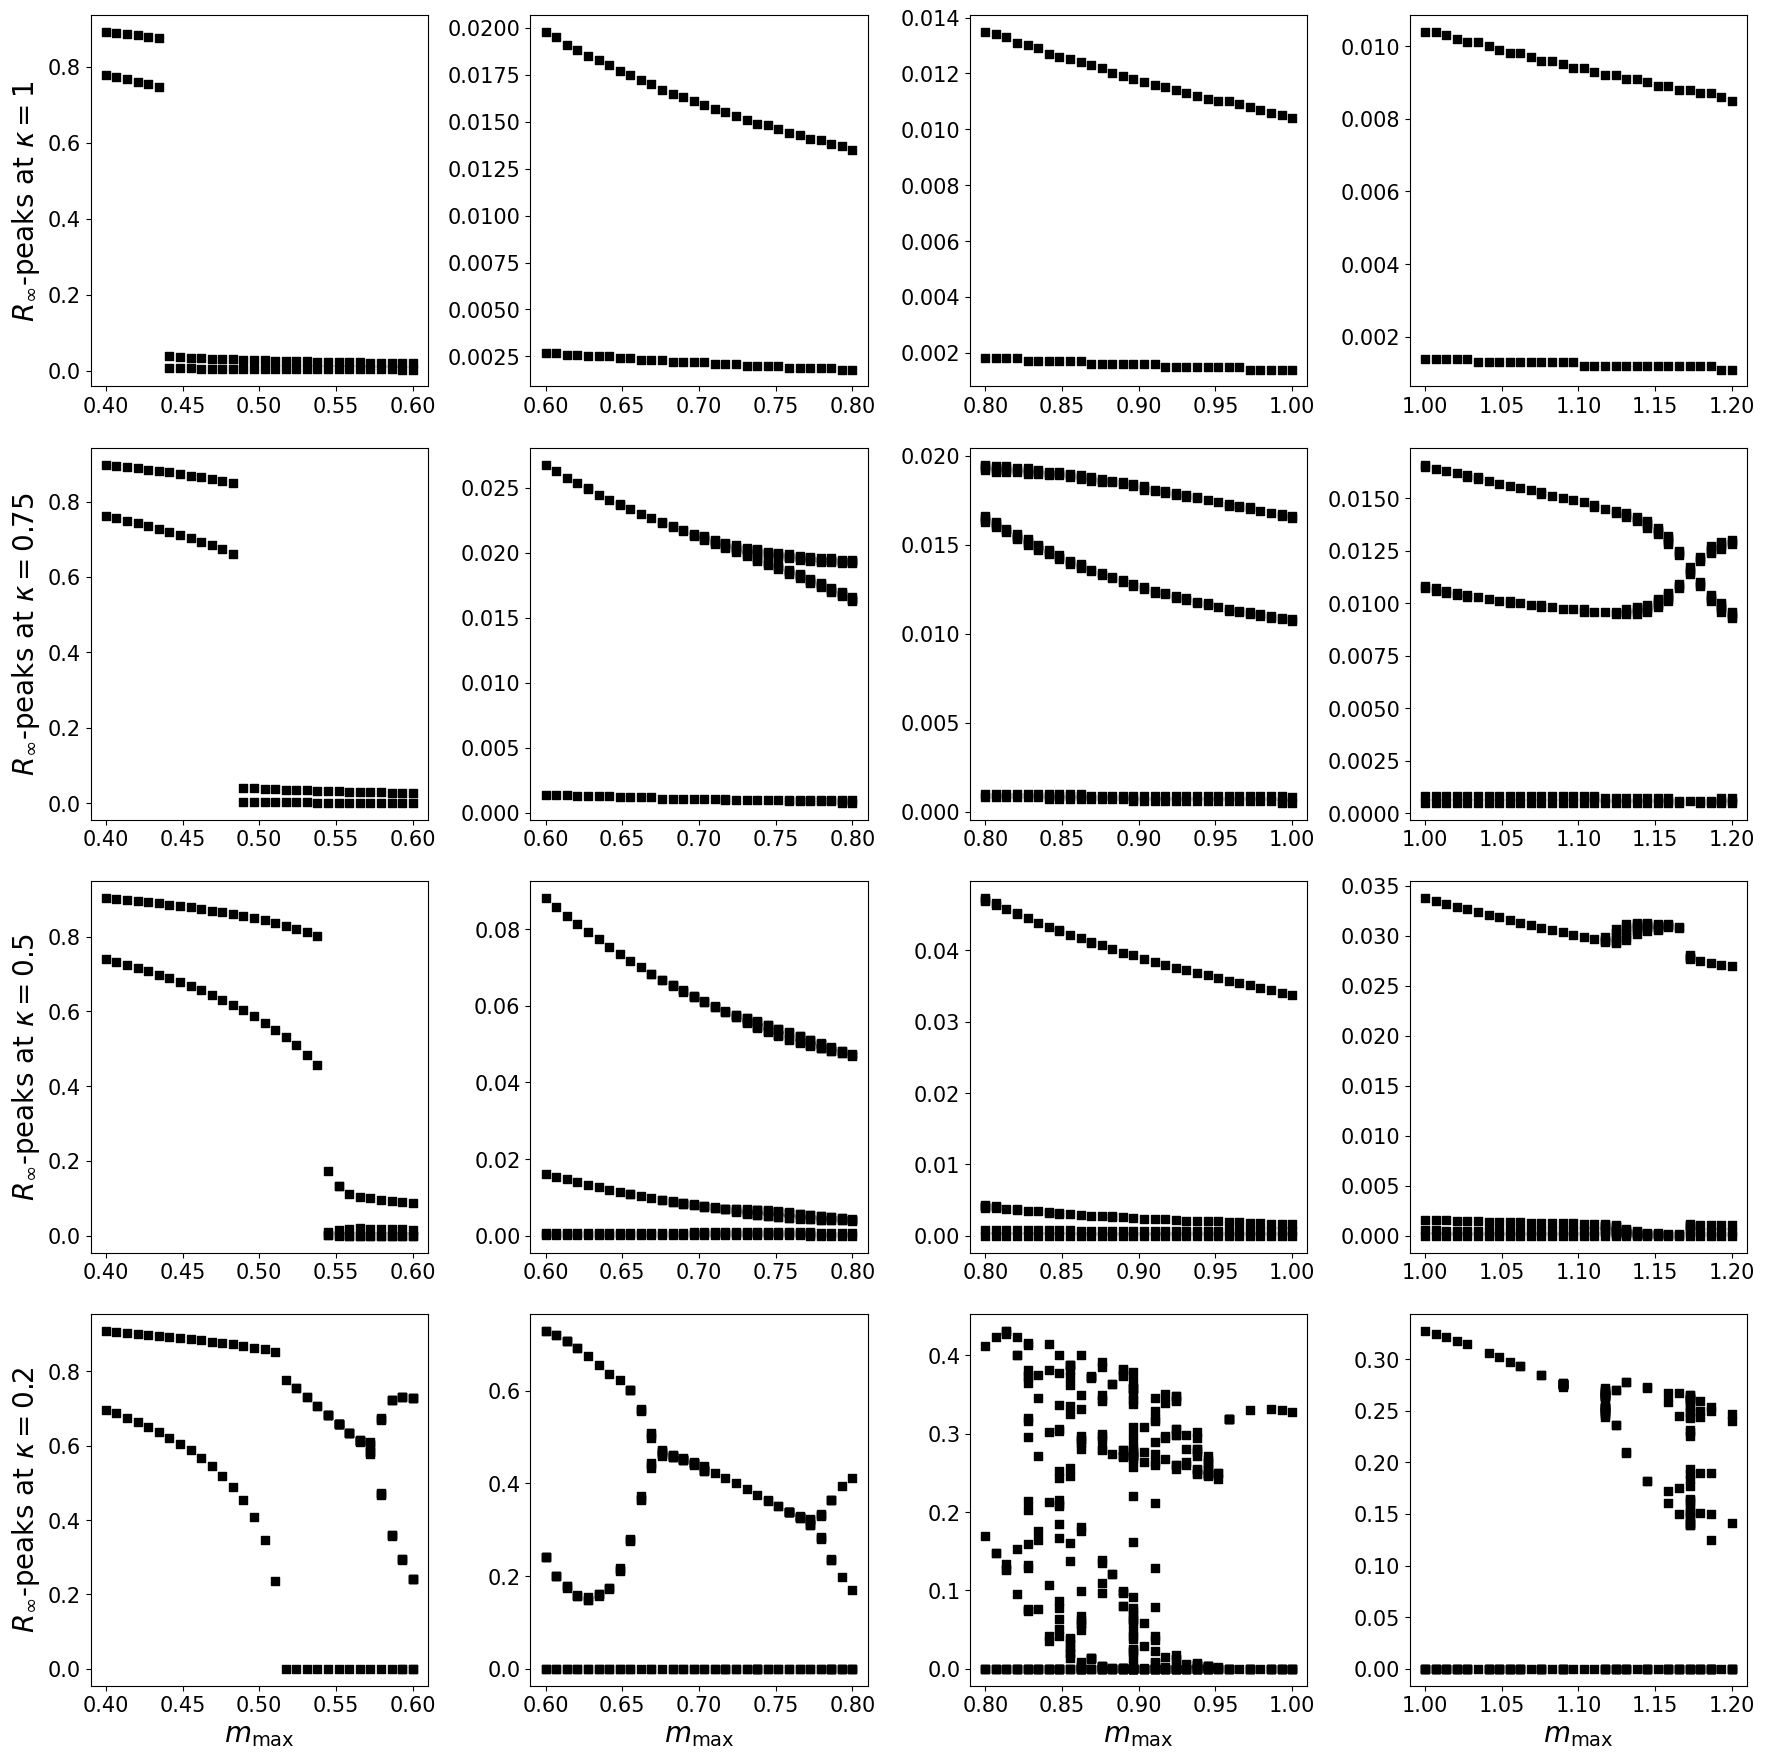

In [51]:
mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

fraction = [1,.75,.5,.2]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for k in range(len(fraction)):
    Peaks = np.load(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction[k]}.npy')
    for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
        ax = axes[k, mmax_val_idx]

        for counter in range(len(Peaks[mmax_val_idx,:,:])): 
            mmax = Peaks[mmax_val_idx, counter, 0]
            if(mmax!=0):
                R_inf = Peaks[mmax_val_idx, counter, 1]
                ax.scatter(mmax, R_inf, marker=',', c='k')
        
        if(k==3): ax.set_xlabel(r'$m_{\rm max}$')
    
        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$-peaks at $\kappa=${fraction[k]}')

plt.tight_layout()
plt.savefig('img/SIRSsm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions_4x4.pdf', bbox_inches='tight')
plt.show()

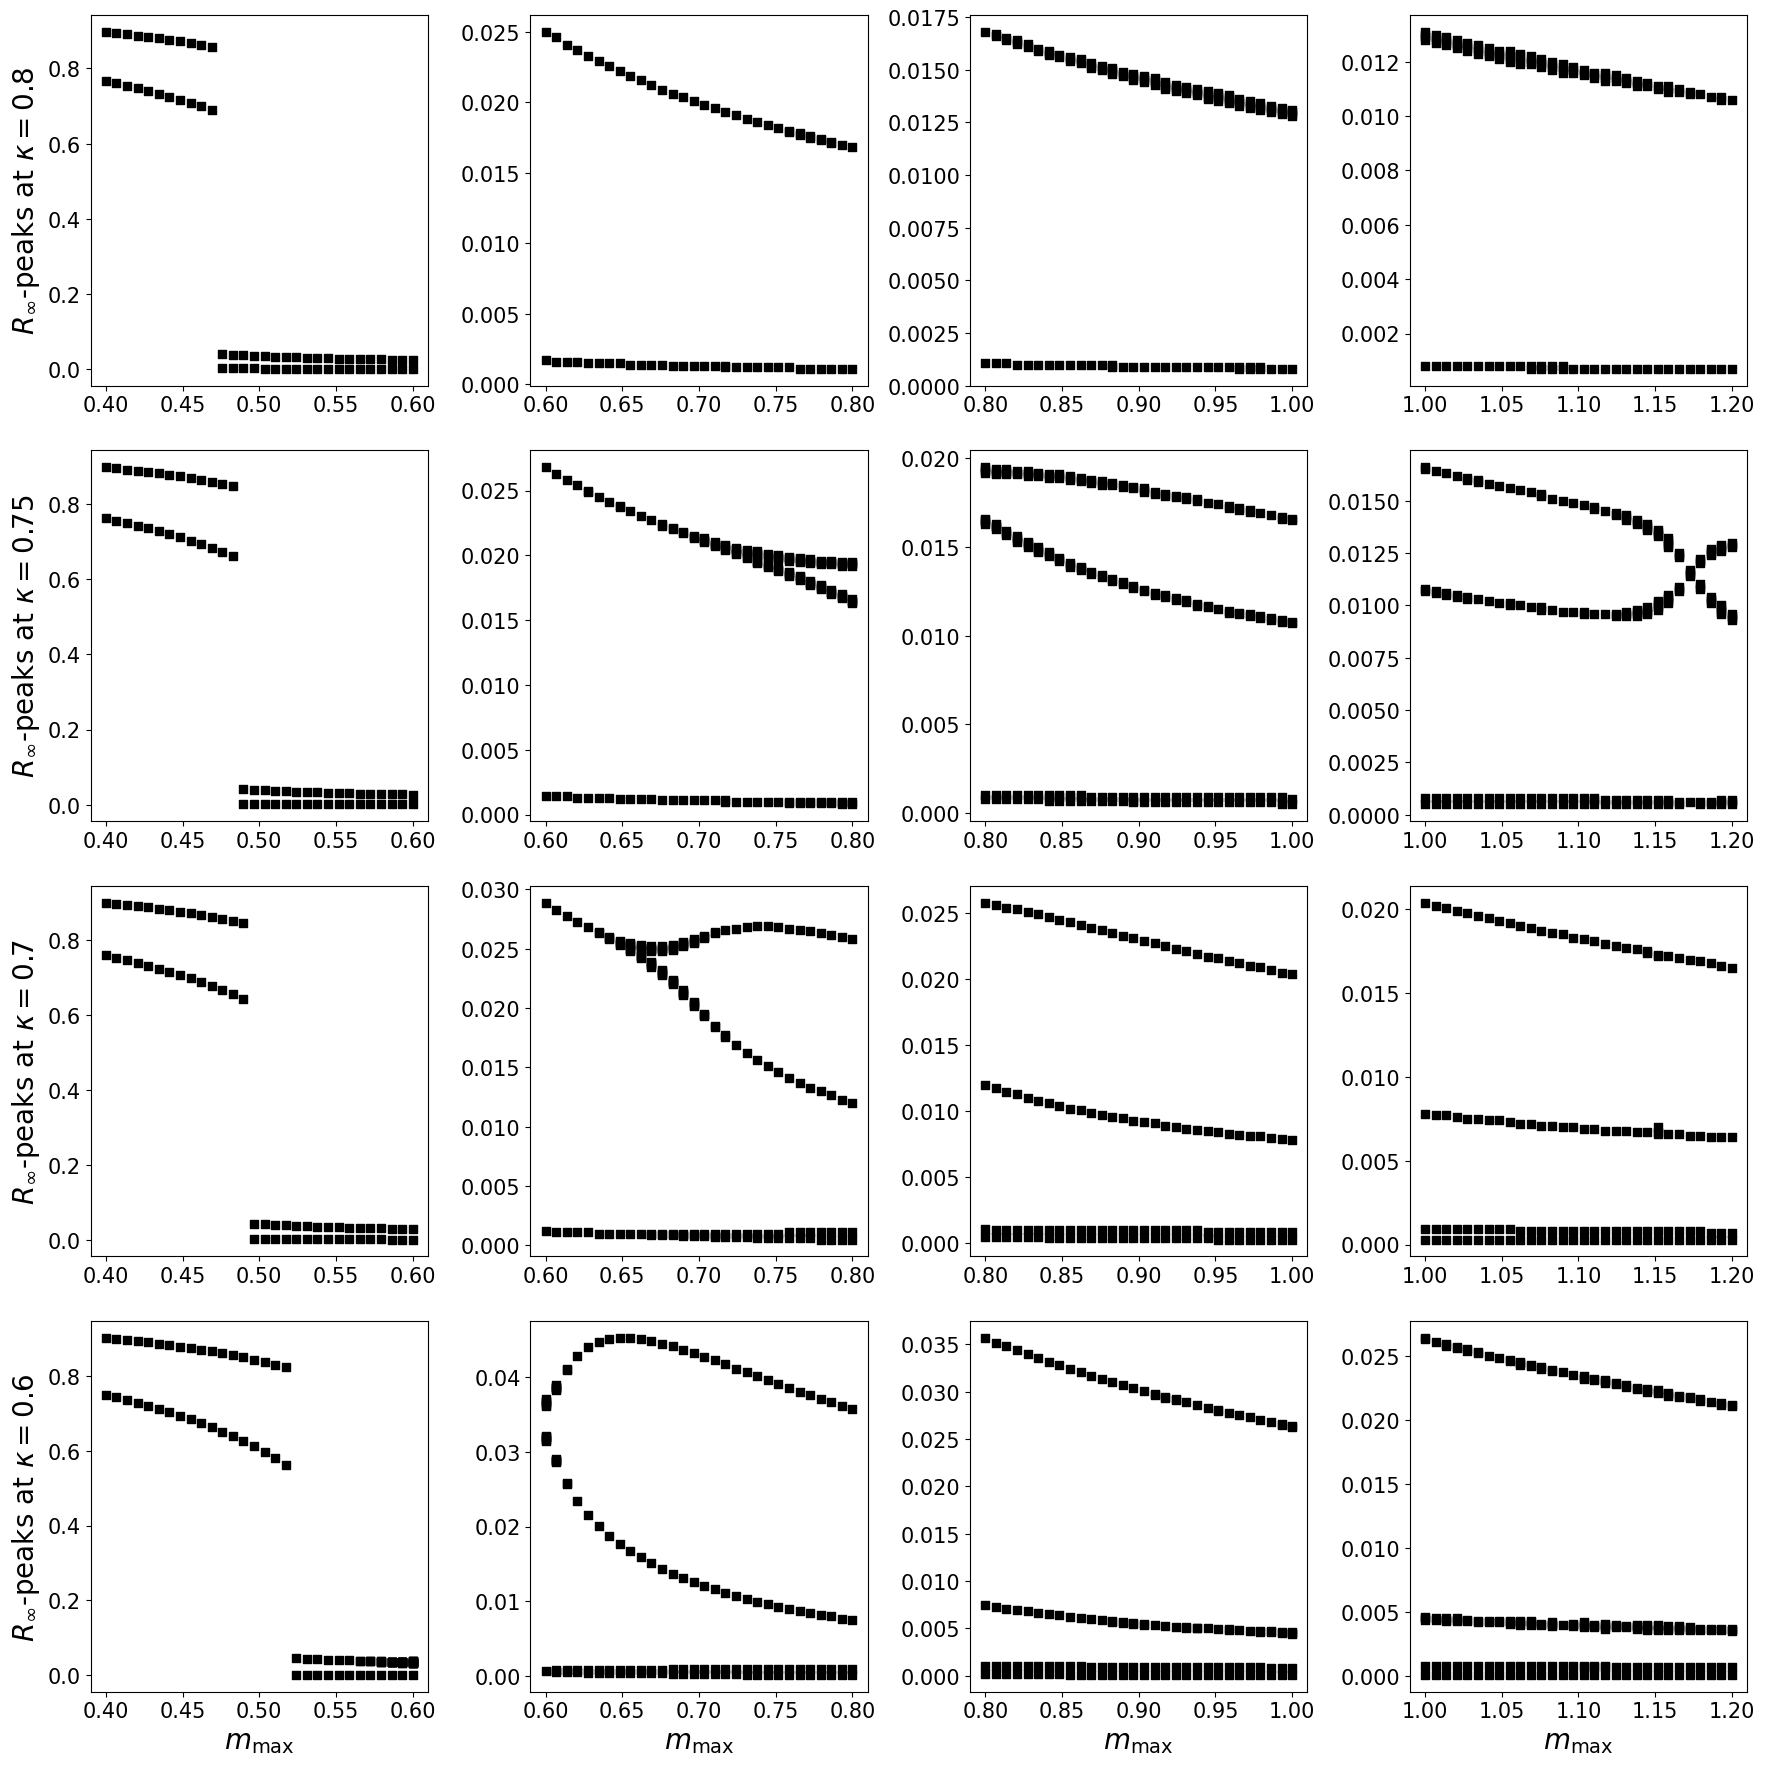

In [93]:
mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

fraction = [.8,.75,.7,.6]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for k in range(len(fraction)):
    Peaks = np.load(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction[k]}.npy')
    for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
        ax = axes[k, mmax_val_idx]

        for counter in range(len(Peaks[mmax_val_idx,:,:])): 
            mmax = Peaks[mmax_val_idx, counter, 0]
            if(mmax!=0):
                R_inf = Peaks[mmax_val_idx, counter, 1]
                ax.scatter(mmax, R_inf, marker=',', c='k')
        
        if(k==3): ax.set_xlabel(r'$m_{\rm max}$')
    
        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$-peaks at $\kappa=${fraction[k]}')

plt.tight_layout()
plt.savefig('img/SIRSsm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions_ZoomInKappa=0.75_4x4.pdf', bbox_inches='tight')
plt.show()

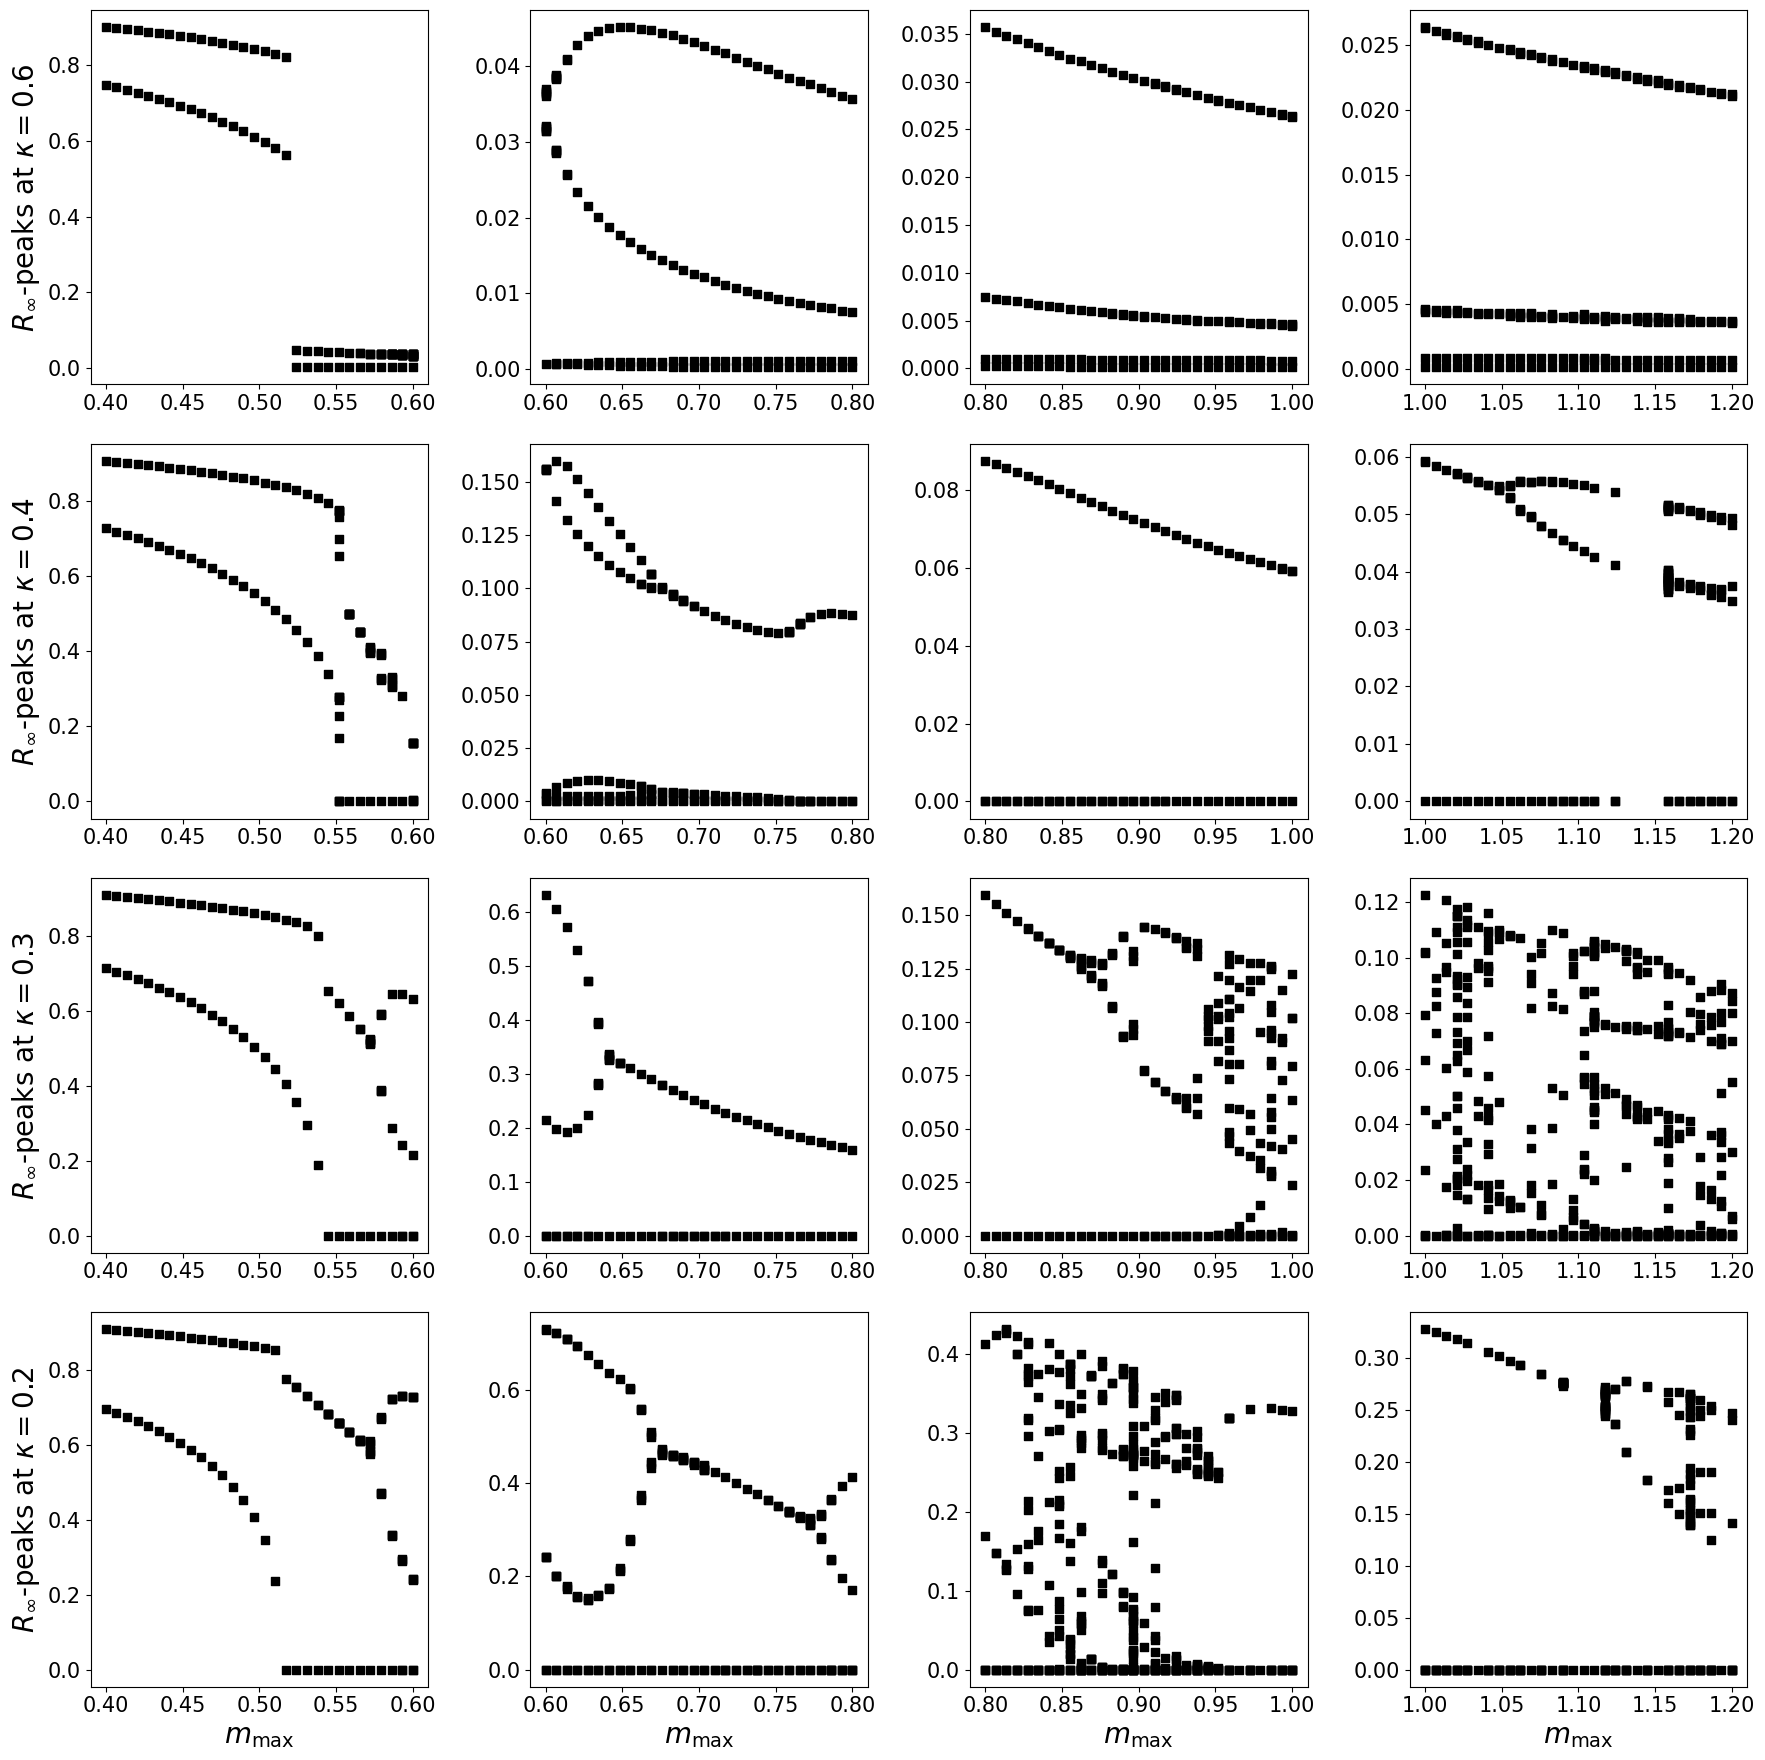

In [55]:
mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

fraction = [0.6,0.4,0.3,0.2]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))


for k in range(len(fraction)):
    Peaks = np.load(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction[k]}.npy')
    for mmax_val_idx, mmax_values in enumerate(mmax_valueList):
        ax = axes[k, mmax_val_idx]

        for counter in range(len(Peaks[mmax_val_idx,:,:])): 
            mmax = Peaks[mmax_val_idx, counter, 0]
            if(mmax!=0):
                R_inf = Peaks[mmax_val_idx, counter, 1]
                ax.scatter(mmax, R_inf, marker=',', c='k')
        
        if(k==3): ax.set_xlabel(r'$m_{\rm max}$')
    
        if(mmax_val_idx==0): ax.set_ylabel(rf'$R_\infty$-peaks at $\kappa=${fraction[k]}')

plt.tight_layout()
plt.savefig('img/SIRSsm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions_ZoomInKappa=0.3_4x4.pdf', bbox_inches='tight')
plt.show()

<font color='red'> At lower right plot 'Solver stopped due to negative population' if tolerances are not lowered

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_34480\3040771785.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=.05,h_pad=.2)


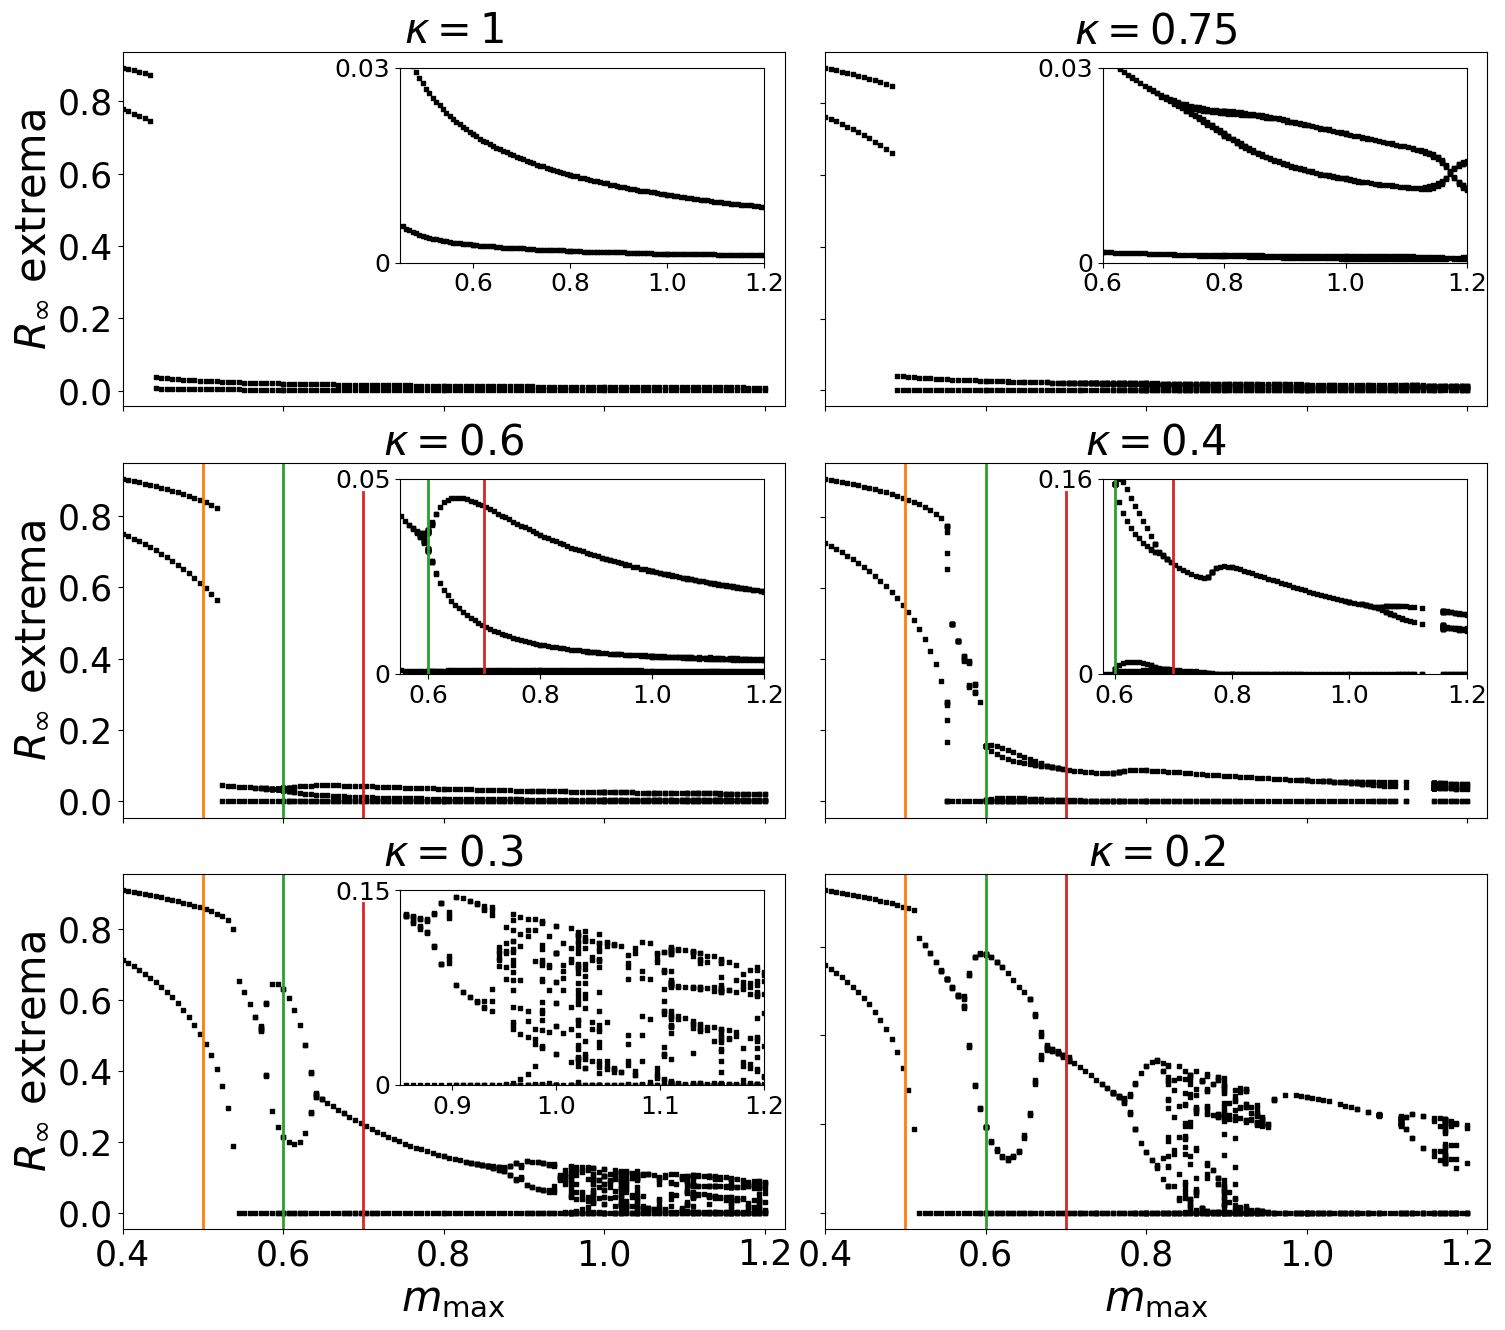

In [33]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

fraction = [1,0.75,0.6,0.4,0.3,0.2]
xLim = np.array([[.45,1.2],[.6,1.2],[.55,1.2],[.58,1.2],[.85,1.2]])
yLim = np.array([[0,.03],[0,.025],[0,.05],[0,.16],[0,.15]])

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
COL = ['tab:blue','tab:orange','tab:green','tab:red']
AxStart = 0 #AxNumberToStartIncludingAxins

for k in range(len(fraction)):
    Peaks = np.load(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction[k]}.npy')

    ax = axes[k//2, k%2]
    ax.set_xlim(mmax_valueList[0,0],mmax_valueList[-1,-1]+.025)
    PlotAxins = k>=AxStart and k<5
    
    # Add inset zoom for the first three panels
    if PlotAxins:
        axins = inset_axes(ax, width="55%", height="55%", loc='upper right', bbox_to_anchor=(-0.015, -0.015, 1, 1), bbox_transform=ax.transAxes)  # shift 1% left down to make space for the highest y and x tick labels
        axins.set_xlim(xLim[k-AxStart,0], xLim[k-AxStart,1])
        axins.set_ylim(yLim[k-AxStart,0], yLim[k-AxStart,1])
        axins.tick_params(axis='x', labelsize=18)
        axins.tick_params(axis='y', labelsize=18) 
        axins.set_yticks([0, yLim[k-AxStart,1]], labels=[f"{0}", f"{yLim[k-AxStart,1]:.2f}"])
        #mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    if k>1:
        for idx,x in enumerate([.2,.5,.6,.7]):
            ax.axvline(x, ls='-', c=COL[idx], lw=2, ymax=.92 if PlotAxins and idx==3 else 1)
            axins.axvline(x, ls='-', c=COL[idx], lw=2)

    for mmax_val_idx, mmax_values in enumerate(mmax_valueList):

        for counter in range(len(Peaks[mmax_val_idx,:,:])): 
            mmax = Peaks[mmax_val_idx, counter, 0]
            if mmax != 0:
                R_inf = Peaks[mmax_val_idx, counter, 1]
                ax.scatter(mmax, R_inf, marker=',', c='k', s=5)
                if PlotAxins and mmax>=xLim[k-AxStart,0] and mmax<=xLim[k-AxStart,1]: axins.scatter(mmax, R_inf, marker=',', c='k', s=5)

    ax.set_title(rf'$\kappa={fraction[k]}$')
    if k>=4: ax.set_xlabel(r'$m_{\rm max}$')
    else: ax.tick_params(labelbottom=False)
    if k%2==0: ax.set_ylabel(r'$R_\infty$ extrema')
    else: ax.tick_params(labelleft=False)
            
plt.tight_layout(w_pad=.05,h_pad=.2)
plt.savefig('img/SIRSsm_BLOCK_LimCyclePeaksBifurcation_mmax_vs_1-S_fordiff_Ratefractions_3x2.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### Mitigation and Seasonality influence Comparison

at mmax= 0.8 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.
at mmax= 1 and Ratefraction= 0.2 ERROR: Solver stopped due to negative population.


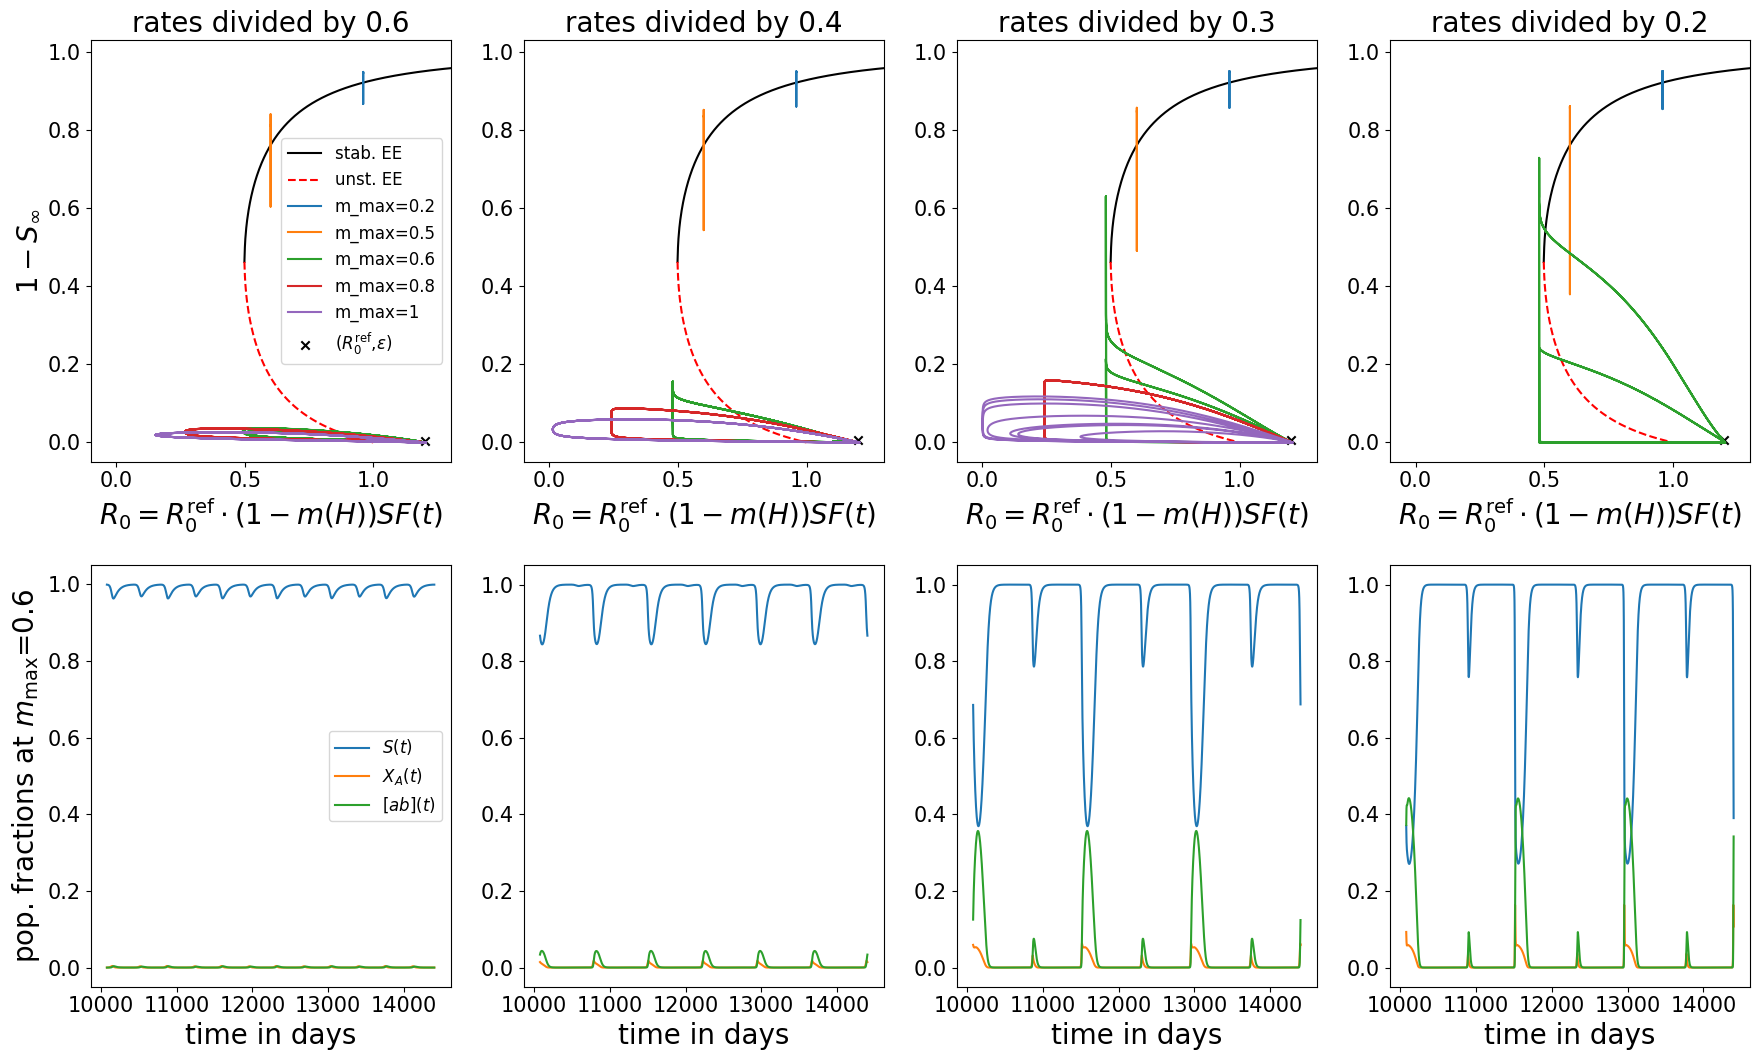

In [16]:
fraction = [.6,.4,.3,.2]
mmax_values = [.2,.5,.6,.8,1]

fig, axes = plt.subplots(2, 4, figsize=(18, 11))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
    p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*7/10)
    
    #################################################

    mmax_timeevolPlot = .6 ############# mmax value to plot trajectories
    p['mmax'] = mmax_timeevolPlot

    m = model(**p)
    times, Data = m.run()
    times = times[cut:]
    S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
    
    ax1 = axes[1, k] 
    ax1.plot(times, S, label=r'$S(t)$')
    ax1.plot(times, A+AB+Ab, label=r'$X_A(t)$')
    ax1.plot(times, ab, label=r'$[ab](t)$')
    #plt.plot(times,Q, label=rf'Q')
    #plt.plot(times,A, label=rf'A')
    #plt.plot(times,AB, label=rf'AB')
    #plt.plot(times,X,label='X')
    ax1.set_xlabel(r'time in days')
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
    
    ax2 = axes[0, k]
    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')    

    for mmax in mmax_values:
        p['mmax'] = mmax
        try: 
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H_1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            SoftPlus = 1 - mmax * m.m_normalized(H)
            
            ax2.plot(p['alpha'] * SoftPlus/p['gamma'], 1 - S, label=rf'm_max={mmax}')
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
    
    ax2.set_xlim(-.1,1.3)
    # ax2.set_ylim(-.02,max(R_inf_PT)+.02)
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0 = R_0^{\rm ref} \cdot (1-m(H))SF(t)$')
    if(k==0):
        ax2.set_ylabel(r'$1-S_\infty$')
        ax1.set_ylabel(f'pop. fractions at $m_{{\\rm max}}$={mmax_timeevolPlot}')
    if(k==0): ax2.legend()
    ax2.set_title(rf'rates divided by {fraction[k]}')

plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig_at_delta=0_fordiff_RateFractions_mmax.pdf')
plt.show()

C:\Users\Rodrigo Amaral Lind\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


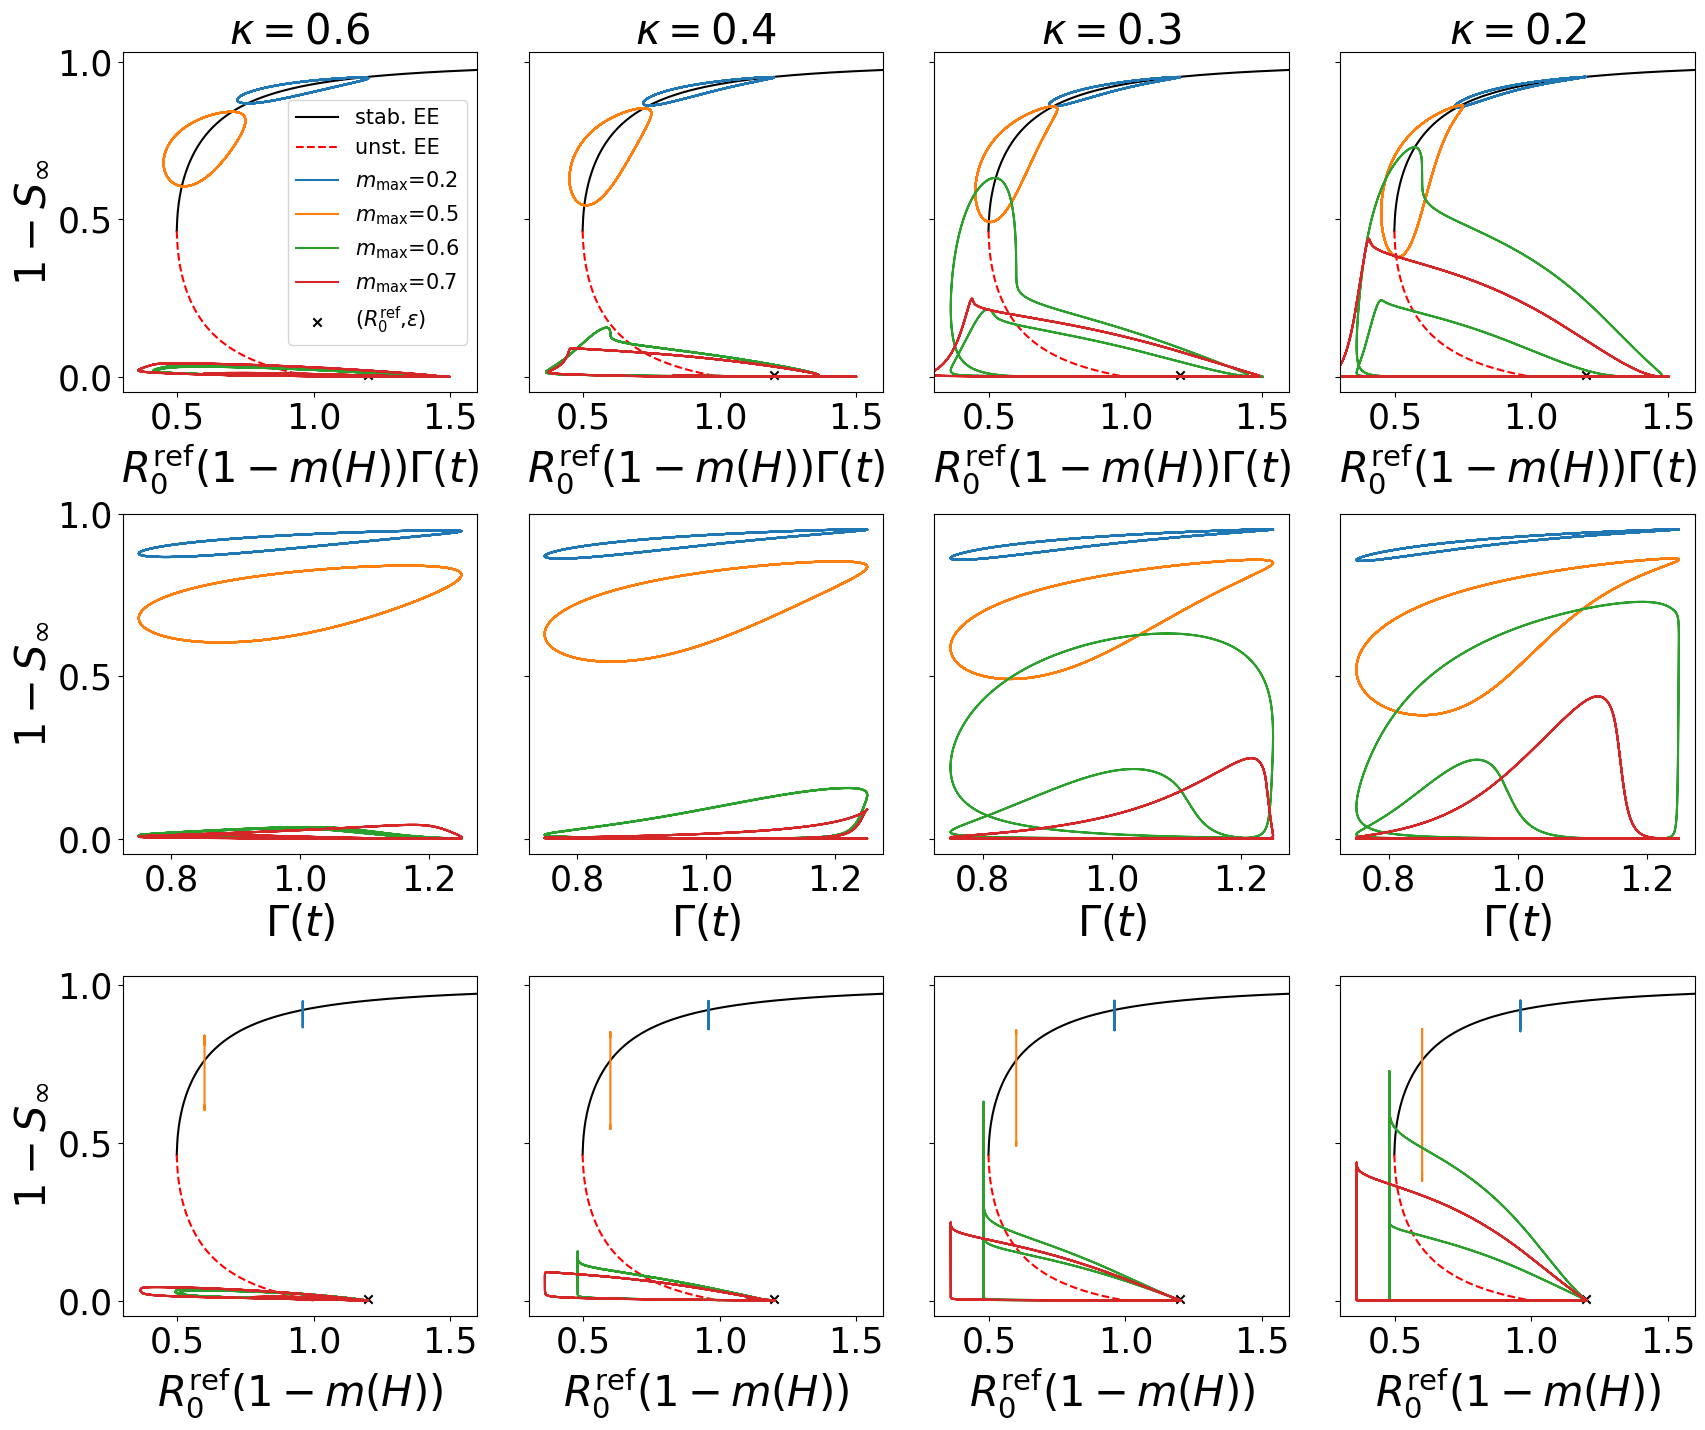

In [28]:
fraction = [.6,.4,.3,.2]
mmax_values = [.2,.5,.6,.7]

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(3, 4, figsize=(18, 15))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
    p['tmax'] = 42*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*8/10)

    
    ###################################################

    # Limit cycles in SoftPLus(mitigated infection rate) vs R_infty for different mmax
    
    ax_mit = axes[2, k]
    ax_seas = axes[1, k]
    ax_mitseas = axes[0, k]

    ax_mit.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax_mit.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
    ax_mitseas.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax_mitseas.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')

    for mmax in mmax_values:
        p['mmax'] = mmax
        p['tmax'] = 42*360
        if(fraction[k]==0.3 and mmax==1): p['tmax'] = 80*360 # if include chaotic case: Want to see it better
        if(fraction[k]<0.3 and mmax>0.6): p['tolerances'] = [1e-15,1e-18]
        try: 
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H_1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            Mitig = mmax * m.m_normalized(H)
            
            ax_mit.plot(p['alpha'] * (1-Mitig)/p['gamma'], 1 - S, label=r'$m_{\rm max}$='+f'{mmax}')
            ax_seas.plot(SF, 1 - S, label=r'$m_{\rm max}$='+f'{mmax}')
            ax_mitseas.plot(p['alpha'] * (1-Mitig) * SF/p['gamma'], 1 - S, label=r'$m_{\rm max}$='+f'{mmax}')
        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        p['tolerances'] = [1e-10,1e-13]
    
    ax_mit.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax_mit.set_xlabel(r'$R_0^{\rm ref}(1-m(H))$')
    ax_mit.set_xlim(.3,1.6)
    # ax_mit.set_ylim(-.02,max(R_inf_PT)+.02)

    #ax_seas.plot(R0_EE, R_inf_endEq, ls='--', c='k', label='stab. EE')
    #ax_seas.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
    #ax_seas.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax_seas.set_xlabel(r'$\Gamma(t)$')

    ax_mitseas.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax_mitseas.set_xlabel(r'$R_0^{\rm ref}(1-m(H))\Gamma(t)$')
    ax_mitseas.set_xlim(.3,1.6)
    # ax_mitseas.set_ylim(-.02,max(R_inf_PT)+.02)

    
    ####################
    if(k==0):
        ax_mit.set_ylabel(r'$1-S_\infty$')
        ax_seas.set_ylabel(r'$1-S_\infty$')
        ax_mitseas.set_ylabel(r'$1-S_\infty$')
        ax_mitseas.legend()
        ax_mit.set_yticks([0,.5,1])
        ax_mitseas.set_yticks([0,.5,1])
        ax_seas.set_yticks([0,.5,1])
    else:
        ax_mit.tick_params(labelleft=False)
        ax_seas.tick_params(labelleft=False)
        ax_mitseas.tick_params(labelleft=False)
    ax_mitseas.set_title(rf'$\kappa=${fraction[k]}')

plt.tight_layout(w_pad=0.03, h_pad=0.1)
plt.savefig('img/SIRSsm_SeasVSMit-InfluenceOnLimitCycles_fordiff_RateFractions_mmax.pdf')
plt.show()

p['tolerances'] = [1e-10,1e-13]

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

### Periodicity of Long term behavior

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_34480\3281176580.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


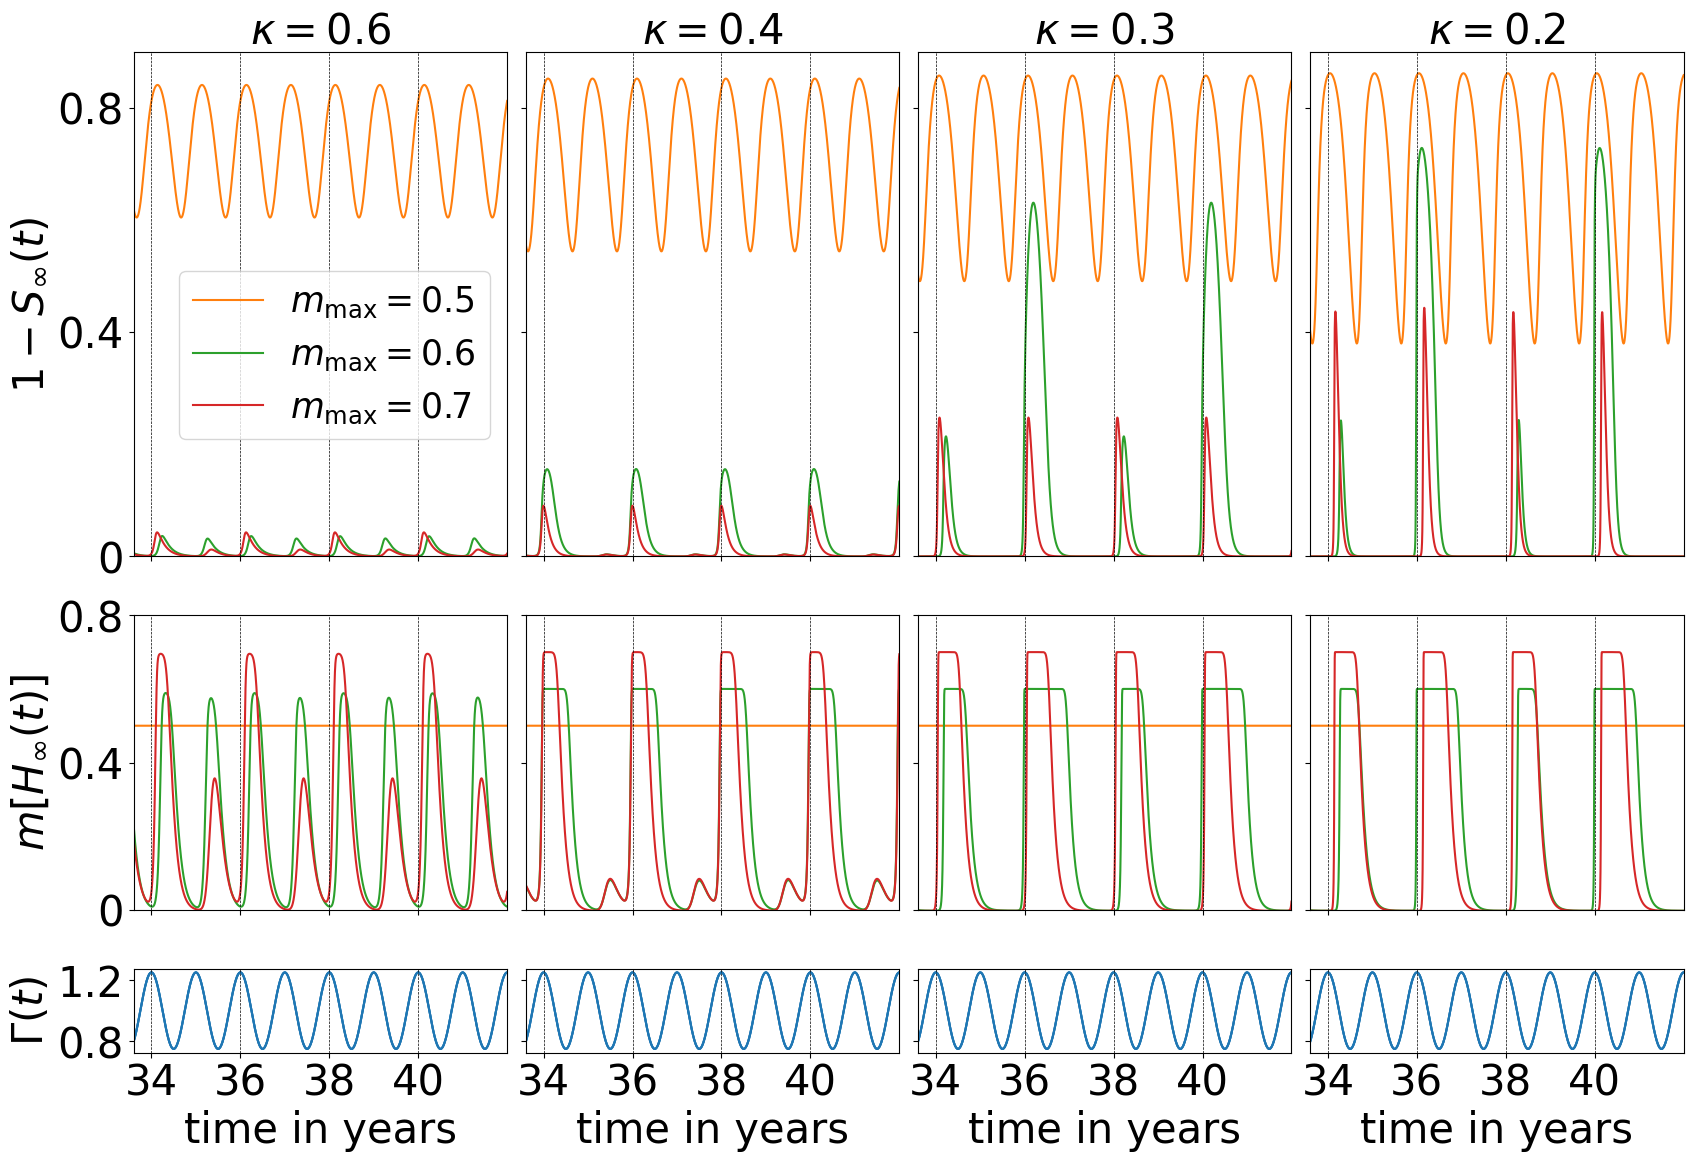

In [34]:
fraction = [.6,.4,.3,.2]
mmax_values = [.5,.6,.7]
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][1:1+len(mmax_values)]

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 25
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(3, 4, figsize=(20, 13), gridspec_kw={'wspace':0.05,'height_ratios': [0.6, 0.35, 0.1]})

for k in range(len(fraction)):

    p['gamma'] = .1/fraction[k]
    p['alpha'] = .12/fraction[k] # alpha_crit/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*.12/fraction[k] # C*alpha_crit/fraction[k]
    p['tmax'] = 42*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*8/10)

    ######################################################
    ax1 = axes[0, k]
    ax_mit = axes[1,k]
    ax_seas = axes[2, k]

    for mmax_idx, mmax in enumerate(mmax_values):
        p['mmax'] = mmax
        if(mmax==1 and fraction[k]==0.3): continue # skip this one (chaotic)
        SetTolerances_for_kappa_mmax(p['mmax'], fraction[k], p)
        try: 
            m = model(**p)
            times, Data = m.run()
            times = times[cut:]
            S,A,B,AB,Ab,aB,a,b,ab,H,H_1 = Data[:,cut:]
            SF = m.seasonalforcing(times)
            mitig = mmax * m.m_normalized(H)
            
            ax1.plot(times/360, 1-S, c=COL[mmax_idx], ls='-', label=rf'$m_{{\rm max}}={mmax}$')
            ax_mit.plot(times/360, mitig, c=COL[mmax_idx])
            ax_seas.plot(times/360, SF, c='tab:blue')

        except RuntimeError as errormessage:
            print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
            pass
        
        if k>0: axes[mmax_idx,k].tick_params(labelleft=False)
        if mmax_idx<2: axes[mmax_idx,k].tick_params(labelbottom=False)

    ####################

    for i in range(int(min(times)/360+1), int(max(times)/360), 2): 
        ax1.axvline(i, ls='--', c='k', lw=0.5)
        ax_mit.axvline(i, ls='--', c='k', lw=0.5)
        ax_seas.axvline(i, ls='--', c='k', lw=0.5)
    
    axes[0,k].set_title(rf'$\kappa=${fraction[k]}')
    axes[2,k].set_xlabel(r'time in years')  
    ax_seas.set_xlabel(r'time in years')

    ax1.set_ylim(0,.9)
    ax_mit.set_ylim(0,.8)
    ax1.set_xlim(min(times)/360,max(times)/360)
    ax_mit.set_xlim(min(times)/360,max(times)/360)
    ax_seas.set_xlim(min(times)/360,max(times)/360)

    ax1.set_yticks([0,.4,.8], labels=[0,.4,.8])
    ax_mit.set_yticks([0,.4,.8], labels=[0,.4,.8])
    ax_seas.set_yticks([.8,1.2], labels=[.8,1.2])
    for ax in [ax1, ax_mit, ax_seas]:
        ax.set_xticks(range(int(min(times)/360+1), int(max(times)/360), 2))

    if(k==0):
        ax1.set_ylabel(f'$1-S_\infty(t)$')
        ax_mit.set_ylabel(r'$m[H_\infty(t)]$')
        ax_seas.set_ylabel(r'$\Gamma(t)$')
    if(k==0): ax1.legend(loc='upper right',bbox_to_anchor=(0,0,1,0.6))

plt.tight_layout()
plt.savefig('img/SIRSsm_Periodicity_fordiff_RateFractions_mmax.pdf', bbox_inches='tight', pad_inches=0.02, dpi=200)
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

<font color = 'red'> For SIRSsm, mitigation is forced to adapt to s periodicity. Therefor its periodicity takes on multiples of a year depending on kappa and mmax. For those of periodicity higher than a year, the year in between has fixed maximum hazard coming from the effect of memory in the erlang kernel which still remembers the last outbreak. In between of multiples of 2 and 4 years for example we get double loops exchanging between higher and lower infections every 2 yrs.

### EXTRA PLOT FOR PAPER

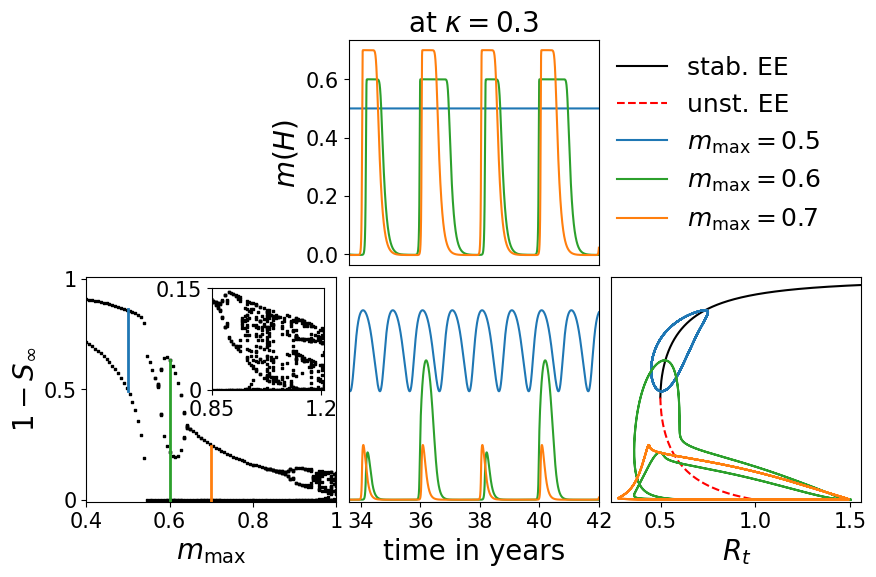

In [26]:
Project = 'Paper' # choose one (coloring is different)
# Project = 'MA'

fraction = 0.3
mmax_values = [.5,.6,.7]
#plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(mmax_values)]
if Project == 'MA': COL = ['tab:orange','tab:green','tab:red'] # for MA
if Project == 'Paper': COL = ['tab:blue','tab:green','tab:orange'] # for Paper

fig, axes = plt.subplots(2, 3, figsize=(10,6))

# Remove the top-left and top-right plots
fig.delaxes(axes[0, 0])
fig.delaxes(axes[0, 2])

ax_evol = axes[1,1]
ax_Bif = axes[1,0]
ax_mitseas = axes[1,2]
ax_mit = axes[0,1]

p['gamma'] = .1/fraction
p['alpha'] = .12/fraction
p['nu'] = .01/fraction
p['beta'] = C*.12/fraction
p['tmax'] = 42*360
cut = int(p['tmax']/p['stepsize']*8/10)

ax_mitseas.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
ax_mitseas.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')

for mmax_idx, mmax in enumerate(mmax_values):
    p['mmax'] = mmax
    SetTolerances_for_kappa_mmax(p['mmax'], fraction, p)
    try: 
        m = model(**p)
        times, Data = m.run()
        times = times[cut:]
        S,A,B,AB,Ab,aB,a,b,ab,H,H_1 = Data[:,cut:]
        SF = m.seasonalforcing(times)
        mitig = mmax * m.m_normalized(H)
        
        ax_evol.plot(times/360, 1-S, c=COL[mmax_idx], ls='-', label=r'$m_{\rm max}=$'+f'{mmax}')
        ax_mit.plot(times/360, mitig, c=COL[mmax_idx])
        ax_mitseas.plot(p['alpha'] * (1-mitig) * SF/p['gamma'], 1 - S, c=COL[mmax_idx], label=r'$m_{\rm max}=$'+f'{mmax}')
        ax_Bif.axvline(mmax, ymin=min(1-S), ymax=max(1-S), ls='-', c=COL[mmax_idx], lw=2)

    except RuntimeError as errormessage:
        print("at mmax=",mmax,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
        pass

#############################

Peaks = np.load(f'Data/DataSIRSsm_LimCyclePeaksBifurcation_mmax_vs_1-S_for_Ratefraction={fraction}.npy')

xLim = np.array([.85,1.2])
yLim = np.array([0,.15])

mmax_valueList = np.array([
    [0.4 + 0.04 * i for i in range(6)],
    [0.6 + 0.04 * i for i in range(6)],
    [0.8 + 0.04 * i for i in range(6)],
    [1 + 0.04 * i for i in range(6)]
])

# Add inset zoom for the first three panels
PlotAxins = True
if PlotAxins:
    axins = inset_axes(ax_Bif, width="45%", height="45%", loc='upper right', bbox_to_anchor=(-0.015, -0.015, 1, 1), bbox_transform=ax_Bif.transAxes)  # shift 1% left down to make space for the highest y and x tick labels
    axins.set_xlim(xLim[0], xLim[1])
    axins.set_ylim(yLim[0], yLim[1])  
    axins.set_yticks([0, yLim[1]], labels=["0", f"{yLim[1]:.2f}"])
    axins.set_xticks([xLim[0], xLim[1]-0.01], labels=[f"{xLim[0]}", f"{xLim[1]}"])
    #mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

for mmax_val_idx in range(len(mmax_valueList)):

        for counter in range(len(Peaks[mmax_val_idx,:,:])): 
            mmax = Peaks[mmax_val_idx, counter, 0]
            if mmax != 0:
                R_inf = Peaks[mmax_val_idx, counter, 1]
                ax_Bif.scatter(mmax, R_inf, marker=',', c='k', s=3)
                if PlotAxins: axins.scatter(mmax, R_inf, marker=',', c='k', s=3)

ax_Bif.set_xlabel(r'$m_{\rm max}$')
ax_Bif.set_xlim(np.concatenate(mmax_valueList)[0],1)
if(Project == 'MA'): ax_Bif.set_ylabel(rf'$R_\infty$')
else: ax_Bif.set_ylabel(rf'$1-S_\infty$')
ax_Bif.set_xticks([0.4,0.6,0.8,1],labels=['0.4','0.6','0.8','1'])

ax_mit.set_title(rf'at $\kappa={fraction}$')
ax_mit.set_ylabel(r'$m(H)$')
ax_evol.set_xlabel('time in years')
if(Project == 'MA'): ax_mitseas.set_xlabel(r'$R_0$')
else: ax_mitseas.set_xlabel(r'$R_t$')

for ax in [ax_Bif, ax_evol, ax_mitseas]:
     ax.set_ylim(-.01,1.01)
     ax.set_yticks([0, 0.5, 1], labels=['0','0.5','1'])
for ax in [ax_mit, ax_evol]:
     ax.set_xlim(times[0]/360,times[-1]/360)
     ax.set_xticks([34,36,38,40,42])

# get rid of labels and axes inbetween
for ax in [ax_evol, ax_mitseas]:
    ax.set_ylabel("")
    ax.set_yticklabels([])
    ax.set_yticks([])
ax_mit.set_xlabel("")
ax_mit.set_xticklabels([])
ax_mit.set_xticks([])
plt.subplots_adjust(
    wspace=0.05,  # horizontal space between subplots
    hspace=0.05   # vertical space between subplots
)

ax_mitseas.set_xlim(0.24,1.56)

# create the legend outside of the plots
handles, labels = ax_mitseas.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right',
    bbox_to_anchor=(0.87, 0.87),
    borderaxespad=0,
    frameon=False,
    fontsize=18
)

plt.savefig(f'img/SIRSsm_DynamicsExampleFor{Project}.pdf')
plt.show()